# Section 2: donor-aware NK-cell contact and kill counts analysis
//

### summary and plotting

In [4]:
from __future__ import annotations

import os
import sys
from pathlib import Path

os.environ.setdefault("PYTENSOR_FLAGS", "optimizer_excluding=fusion")
os.environ.setdefault("HDF5_USE_FILE_LOCKING", "FALSE")

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    import scienceplots  # noqa: F401

    plt.style.use("science")
except ModuleNotFoundError:
    plt.style.use("default")


def find_project_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)

    for candidate in (start, *start.parents):
        if (
            (candidate / "section_2/src/inference_donor_relative.py").exists()
            and (candidate / "data").is_dir()
        ):
            return candidate

    raise RuntimeError("Could not locate the project root.")


PROJECT_ROOT = find_project_root()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_ROOT = PROJECT_ROOT / "data"
RESULT_ROOT = PROJECT_ROOT / "section_2/results/analysis_1_donor_summary"
FIGURE_ROOT = PROJECT_ROOT / "section_2/figures/analysis_1_donor_summary"

for directory in (RESULT_ROOT, FIGURE_ROOT):
    directory.mkdir(parents=True, exist_ok=True)

In [15]:
CONDITIONS = {
    "no_treatment": {
        "label": "No treatment",
        "path": DATA_ROOT / "Donor-info_NT.csv",
    },
    "rtx": {
        "label": "Rituximab",
        "path": DATA_ROOT / "Donor-info_RTX.csv",
    },
    "bispecific": {
        "label": "Bispecific mAb",
        "path": DATA_ROOT / "Donor-info_Bispecific.csv",
    },
}
CONDITIONS_PLOT = {key: value["label"] for key, value in CONDITIONS.items()}

CONDITION_ORDER = ["No treatment", "Rituximab", "Bispecific Ab"]
OUTCOME_ORDER = ["contacts", "kills"]

## Importation of the `idata` from inference

In [6]:
INFERENCE_RESULT_ROOT = (
    PROJECT_ROOT / "section_2/results/analysis_1_donor_logscale"
)
MODEL_ORDER = ["homo", "Z2P", "Dis2P", "hetero3"]


def slug(text: str) -> str:
    return text.lower().replace(" ", "_").replace("-", "_")


def load_idata(
    condition: str,
    outcome: str,
    model: str,
) -> az.InferenceData:
    posterior_path = (
        INFERENCE_RESULT_ROOT
        / slug(condition)
        / slug(outcome)
        / f"posterior_{model}_donor_smc.nc"
    )
    if not posterior_path.is_file():
        raise FileNotFoundError(f"Posterior not found: {posterior_path}")
    return az.from_netcdf(str(posterior_path))


# Keep this small when analysing one model. Use MODEL_ORDER to load all 24 fits.
MODELS_TO_LOAD = ["Dis2P"]

posterior_data = {
    (condition, outcome, model): load_idata(condition, outcome, model)
    for condition in CONDITION_ORDER
    for outcome in OUTCOME_ORDER
    for model in MODELS_TO_LOAD
}

# Example: one ArviZ InferenceData object.
# idata = posterior_data[("No treatment", "contacts", "Dis2P")]
# print(f"Loaded {len(posterior_data)} posterior fits")
# idata


## Plot 1. Within- and between-donor variance decomposition

The two components add on the **variance** at population scale:

$$V_{\mathrm{within-donor}} = \sum_d \widetilde{w}_d\sigma_{\lambda,d}^2,$$

$$V_{\mathrm{between-donors}} = \sum_d \widetilde{w}_d(\mu_{\lambda,d}-\bar{\mu}_{\lambda})^2,$$

$$\bar{\sigma}_{\lambda} = \sqrt{V_{\mathrm{within}}+V_{\mathrm{between}}}.$$


In [7]:
def decompose_population_sigma(idata: az.InferenceData):
    posterior = idata.posterior
    required = {
        "active_donor_weights",
        "mu_lambda_donor",
        "sigma_lambda_donor",
        "sigma_lambda_population",
    }
    missing = sorted(required.difference(posterior.data_vars))
    if missing:
        raise ValueError(f"Posterior is missing variables: {missing}")

    weights = posterior["active_donor_weights"]
    mu_donor = posterior["mu_lambda_donor"]
    sigma_donor = posterior["sigma_lambda_donor"]

    if not np.allclose(weights.sum("donor").values, 1.0):
        raise ValueError("Donor weights do not sum to one")

    mu_population = (weights * mu_donor).sum("donor")
    within_variance = (weights * sigma_donor**2).sum("donor")
    between_variance = (
        weights * (mu_donor - mu_population) ** 2
    ).sum("donor")
    total_variance = within_variance + between_variance
    population_sd = np.sqrt(total_variance)

    decomposition = within_variance.to_dataset(
        name="within_donor_variance"
    )
    decomposition["between_donor_variance"] = between_variance
    decomposition["total_variance"] = total_variance
    decomposition["within_donor_sd_component"] = np.sqrt(
        within_variance
    )
    decomposition["between_donor_sd_component"] = np.sqrt(
        between_variance
    )
    decomposition["population_sd_reconstructed"] = population_sd
    decomposition["population_sd_saved"] = posterior[
        "sigma_lambda_population"
    ]
    decomposition["within_variance_fraction"] = (
        within_variance / total_variance
    ).where(total_variance > 0.0)
    decomposition["between_variance_fraction"] = (
        between_variance / total_variance
    ).where(total_variance > 0.0)

    max_error = float(
        np.abs(
            population_sd - posterior["sigma_lambda_population"]
        ).max()
    )
    if max_error > 1e-10:
        raise AssertionError(
            f"Reconstructed population SD differs by {max_error:.3e}"
        )
    decomposition.attrs["max_abs_reconstruction_error"] = max_error

    return decomposition


In [8]:
idata = posterior_data[("No treatment", "contacts", "Dis2P")]
sigma_parts = decompose_population_sigma(idata)
print(
    "Maximum reconstruction error:",
    sigma_parts.attrs["max_abs_reconstruction_error"],
)

within_donor_variance = sigma_parts['within_donor_variance']
between_donor_variance = sigma_parts['between_donor_variance']

print("Within-donor variance (mean):", float(within_donor_variance.mean()))
print("Between-donor variance (mean):", float(between_donor_variance.mean()))

Maximum reconstruction error: 2.6645352591003757e-15
Within-donor variance (mean): 1.1369346812529295
Between-donor variance (mean): 0.23987476470530797


In [9]:
within_dir = {}
between_dir = {}

for data_type in OUTCOME_ORDER:
    for treat in CONDITION_ORDER:
        idata = posterior_data[(treat, data_type, "Dis2P")]
        sigma_parts = decompose_population_sigma(idata)
        within_donor_variance = sigma_parts['within_donor_variance']
        between_donor_variance = sigma_parts['between_donor_variance']
        print(
            "Maximum reconstruction error:",
            sigma_parts.attrs["max_abs_reconstruction_error"],
            )

        within_dir[(treat, data_type)] = float(within_donor_variance.mean())
        between_dir[(treat, data_type)] = float(between_donor_variance.mean())
        print(f"{treat} - {data_type}: Within-donor variance (mean): {within_dir[(treat, data_type)]}")
        print(f"{treat} - {data_type}: Between-donor variance (mean): {between_dir[(treat, data_type)]} \n")   

Maximum reconstruction error: 2.6645352591003757e-15
No treatment - contacts: Within-donor variance (mean): 1.1369346812529295
No treatment - contacts: Between-donor variance (mean): 0.23987476470530797 

Maximum reconstruction error: 2.9976021664879227e-15
Rituximab - contacts: Within-donor variance (mean): 0.9553140987779071
Rituximab - contacts: Between-donor variance (mean): 0.5680300446846238 

Maximum reconstruction error: 3.9968028886505635e-15
Bispecific Ab - contacts: Within-donor variance (mean): 0.8938159464230517
Bispecific Ab - contacts: Between-donor variance (mean): 0.24506886602342115 

Maximum reconstruction error: 9.992007221626409e-16
No treatment - kills: Within-donor variance (mean): 0.6637119014867462
No treatment - kills: Between-donor variance (mean): 0.10447251540949387 

Maximum reconstruction error: 2.1094237467877974e-15
Rituximab - kills: Within-donor variance (mean): 0.6030079023225491
Rituximab - kills: Between-donor variance (mean): 0.229612671221861 

M

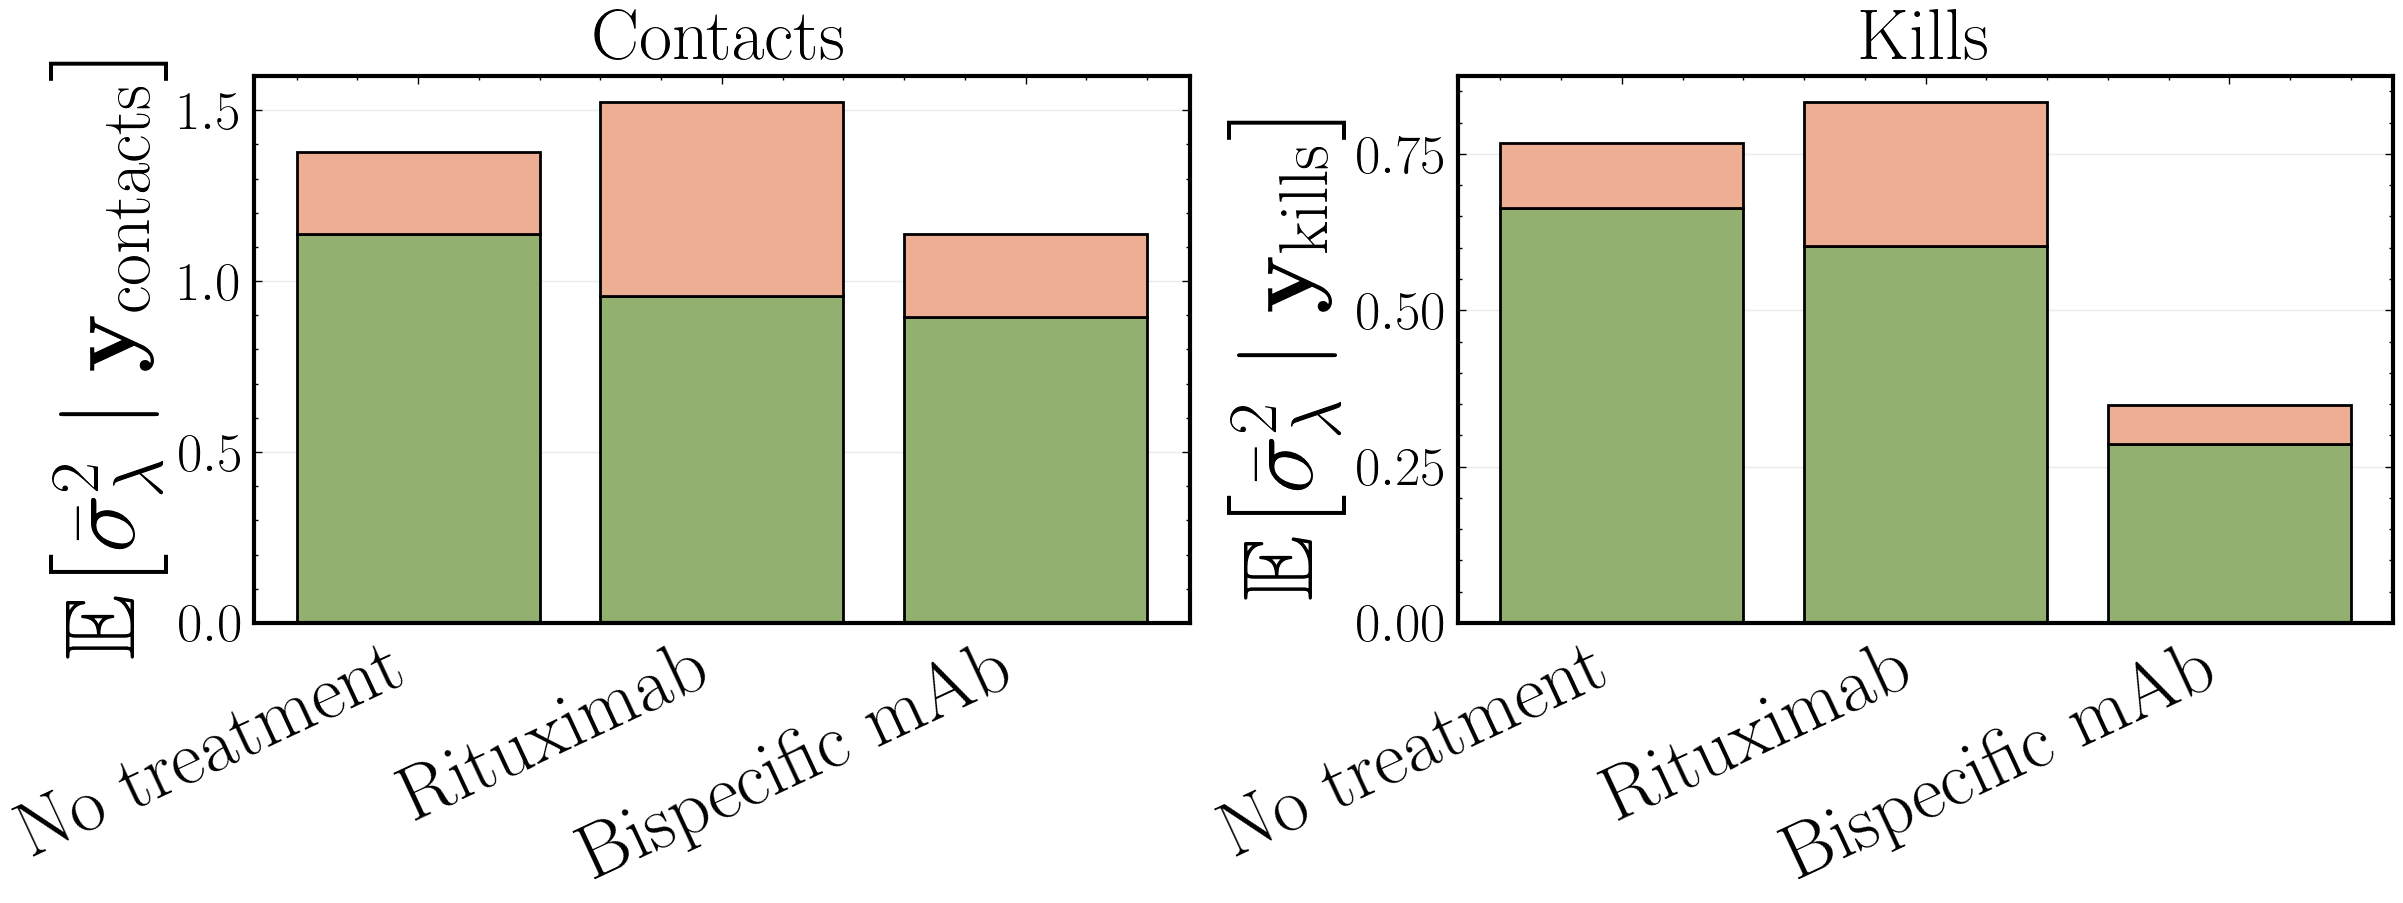

In [16]:
within_color = "#93b071"
between_color = "#edae93"

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4.5),
    dpi=200,
    constrained_layout=True,
)

x = np.arange(len(CONDITION_ORDER))

for ax, data_type in zip(axes, OUTCOME_ORDER):
    within_values = np.array(
        [within_dir[(treat, data_type)] for treat in CONDITION_ORDER]
    )
    between_values = np.array(
        [between_dir[(treat, data_type)] for treat in CONDITION_ORDER]
    )

    ax.bar(
        x,
        within_values,
        color=within_color,
        edgecolor="black",
        linewidth=1,
        label="within-donor variance",
    )

    ax.bar(
        x,
        between_values,
        bottom=within_values,
        color=between_color,
        edgecolor="black",
        linewidth=1,
        label="between-donor variance",
    )

    ax.set_xticks(x)
    ax.set_xticklabels(CONDITIONS_PLOT.values(), rotation=25, ha="right", fontsize=28)
    # ax.set_xlabel("Treatment")
    ax.set_ylabel(
        rf"$\mathbb{{E}}\!\left["
        rf"\bar{{\sigma}}_{{\lambda}}^2"
        rf"\mid \mathbf{{y}}_{{\mathrm{{{data_type}}}}}"
        rf"\right]$",
        fontsize=36,
    )
    ax.set_title(data_type.capitalize(), fontsize=26)
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
    
    ax.tick_params(
        axis="y",
        labelsize=20
    )    
    
    fig.patch.set_alpha(0)
    ax.set_facecolor("none")

    

# axes[1].legend(frameon=True)

plt.savefig(
    FIGURE_ROOT / "variance_decomposition_barplot.svg",
    dpi=300,
    bbox_inches="tight",
    transparent=True,
    facecolor="none",
    edgecolor="none",
)
plt.show()

## Plot 2. No Treatment $\mu_{\lambda, d}$ heterogeneity

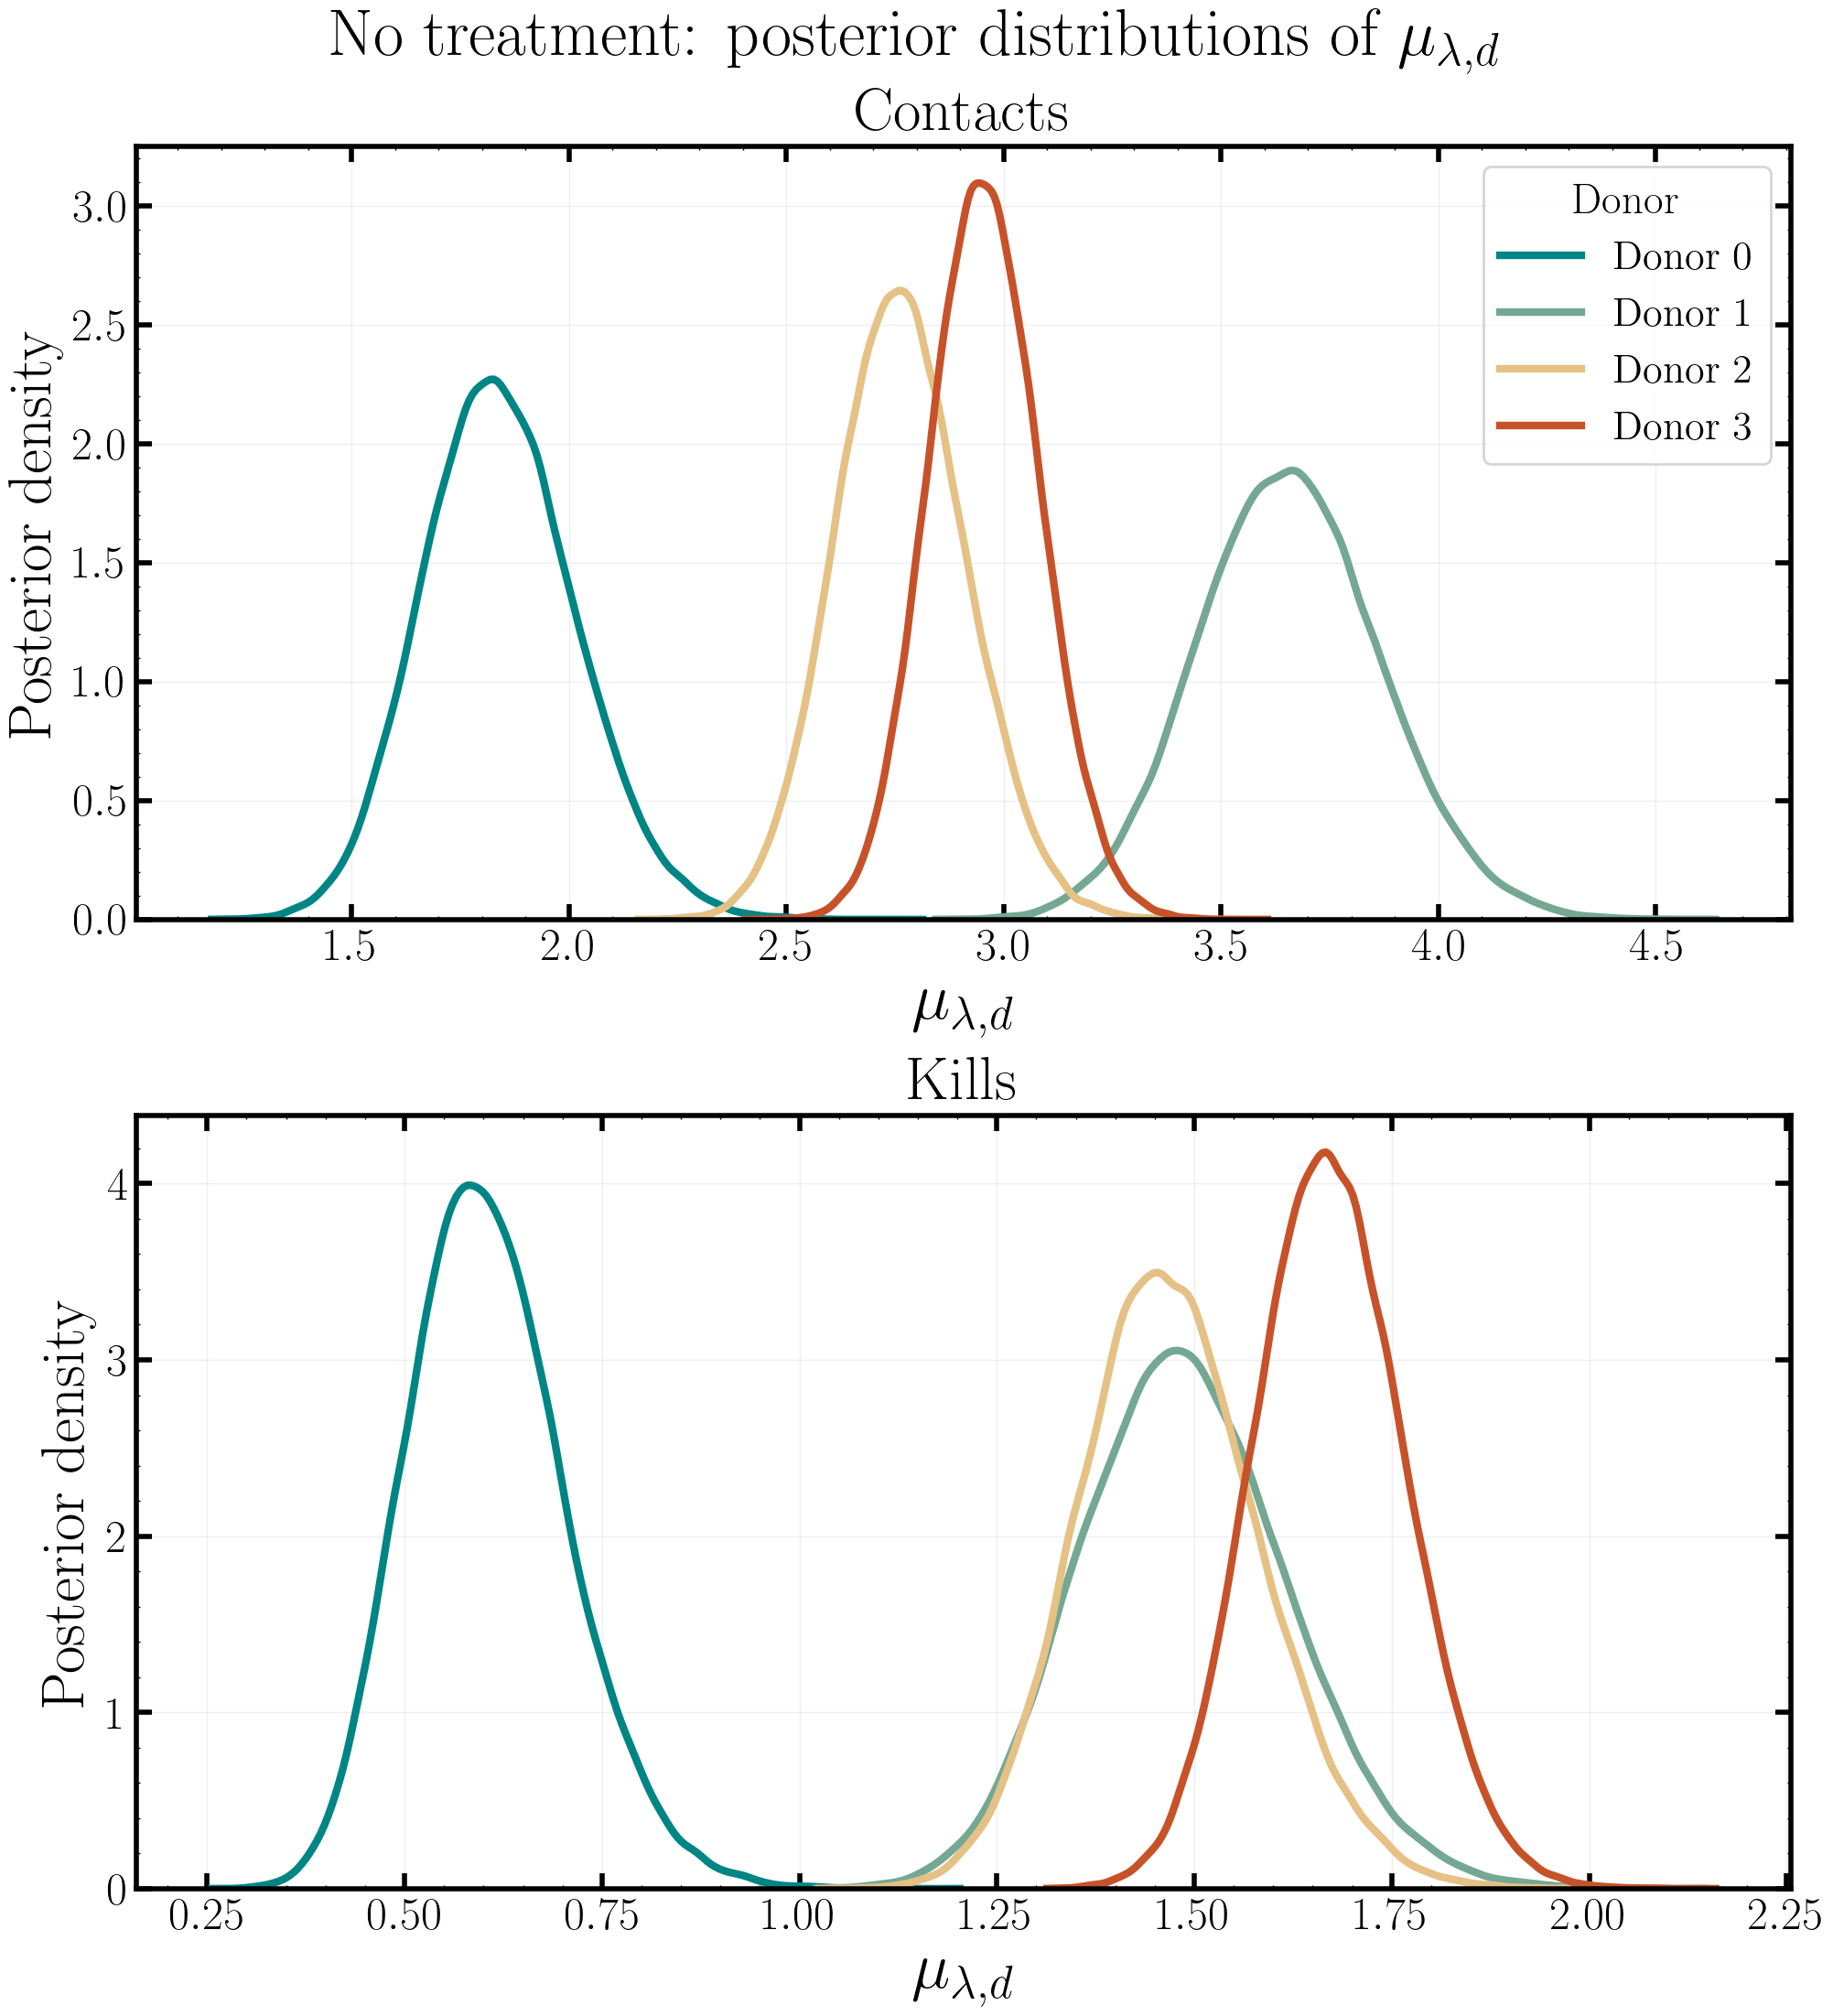

In [11]:
DONOR_COLOR_VALUES = [
    "#008585",
    "#74a892",
    "#e5c185",
    "#c7522a",
]

DONOR_LABELS = [0, 1, 2, 3]
TREATMENT = "No treatment"

fig, axes = plt.subplots(
    2,
    1,
    figsize=(10, 11),
    dpi=200,
    constrained_layout=True,
)

for ax, outcome in zip(axes, OUTCOME_ORDER):
    idata = posterior_data[(TREATMENT, outcome, "Dis2P")]

    for donor_index, (donor_label, color) in enumerate(
        zip(DONOR_LABELS, DONOR_COLOR_VALUES)
    ):
        samples = (
            idata.posterior["mu_lambda_donor"]
            .isel(donor=donor_index)
            .values
            .reshape(-1)
        )

        sns.kdeplot(
            x=samples,
            ax=ax,
            color=color,
            linewidth=3,
            fill=False,
            cut=0,
            label=f"Donor {donor_label}",
        )
        
        
    ax.set_title(outcome.capitalize(), fontsize=24)
    ax.set_xlabel(r"$\mu_{\lambda,d}$", fontsize=26)
    ax.set_ylabel("Posterior density", fontsize=24)

    ax.tick_params(
        axis="both",
        labelsize=18,
        width=2,
        length=6,
    )

    ax.grid(alpha=0.2)
    ax.set_axisbelow(True)

    for spine in ax.spines.values():
        spine.set_linewidth(2)

axes[0].legend(
    title="Donor",
    fontsize=16,
    title_fontsize=17,
    frameon=True,
)

fig.suptitle(
    r"No treatment: posterior distributions of $\mu_{\lambda,d}$",
    fontsize=26,
)
fig.savefig(
    FIGURE_ROOT / "posterior_mu_lambda_donor_kde.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True,
    facecolor="none",
    edgecolor="none",
)

plt.show()

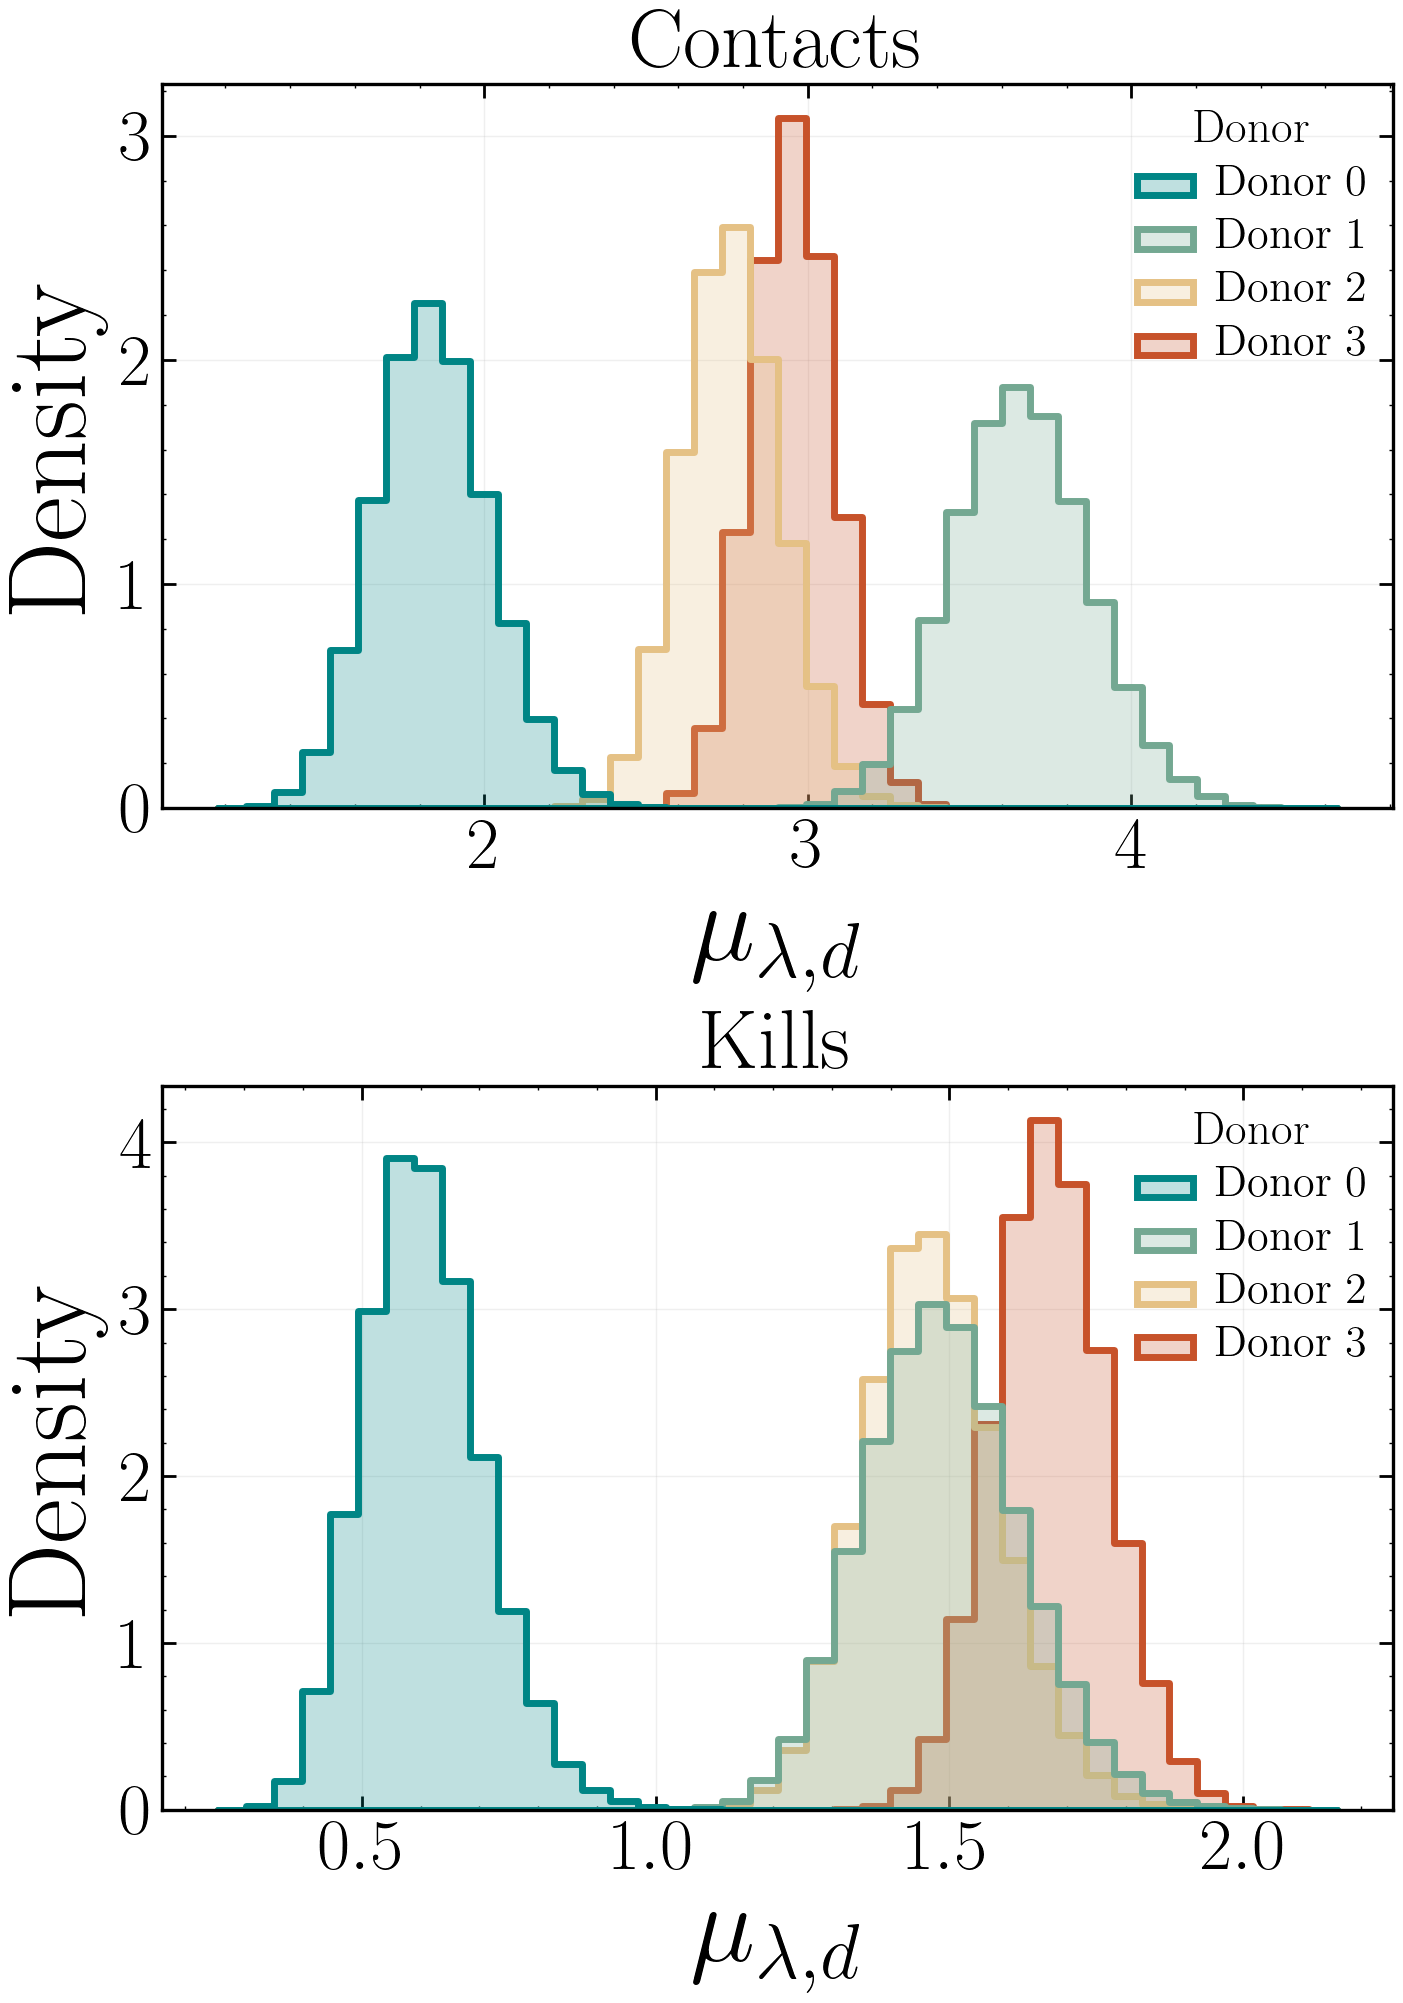

In [12]:
DONOR_COLOR_VALUES = [
    "#008585",
    "#74a892",
    "#e5c185",
    "#c7522a",
]

DONOR_LABELS = [0, 1, 2, 3]
DONOR_NAMES = [f"Donor {donor}" for donor in DONOR_LABELS]

DONOR_PALETTE = dict(
    zip(DONOR_NAMES, DONOR_COLOR_VALUES)
)

TREATMENT = "No treatment"

fig, axes = plt.subplots(
    2,
    1,
    figsize=(7, 10),
    dpi=200,
    constrained_layout=True,
)

for ax, outcome in zip(axes, OUTCOME_ORDER):
    idata = posterior_data[
        (TREATMENT, outcome, "Dis2P")
    ]

    posterior_frames = []

    for donor_index, donor_name in enumerate(DONOR_NAMES):
        samples = (
            idata.posterior["mu_lambda_donor"]
            .isel(donor=donor_index)
            .values
            .reshape(-1)
        )

        posterior_frames.append(
            pd.DataFrame(
                {
                    "mu_lambda_donor": samples,
                    "donor": donor_name,
                }
            )
        )

    posterior_df = pd.concat(
        posterior_frames,
        ignore_index=True,
    )

    sns.histplot(
        data=posterior_df,
        x="mu_lambda_donor",
        hue="donor",
        hue_order=DONOR_NAMES,
        palette=DONOR_PALETTE,
        element="step",
        stat="density",
        common_norm=False,
        bins=40,
        linewidth=2.5,
        ax=ax,
    )
    

    ax.set_title(
        outcome.capitalize(),
        fontsize=30,
    )
    ax.set_xlabel(
        r"$\mu_{\lambda,d}$",
        fontsize=40,
    )
    ax.set_ylabel(
        "Density",
        fontsize=40,
    )

    ax.tick_params(
        axis="both",
        labelsize=26,
        width=1,
        length=5,
    )

    ax.grid(alpha=0.2)
    ax.set_axisbelow(True)

    for spine in ax.spines.values():
        spine.set_linewidth(1.2)
        
    fig.patch.set_alpha(0)
    ax.set_facecolor("none")
    
    legend = ax.get_legend()
    legend.set_title("Donor")
    legend.get_title().set_fontsize(17)

    for text in legend.get_texts():
        text.set_fontsize(16)

# fig.suptitle(
#     r"No treatment: posterior distributions of $\mu_{\lambda,d}$",
#     fontsize=26,
# )
fig.savefig(
    FIGURE_ROOT / "posterior_mu_lambda_donor_hist.svg",
    dpi=300,
    bbox_inches="tight",
    transparent=True,
    facecolor="none",
    edgecolor="none",
)

plt.show()

## Plot 3. Antibody treatment effects.

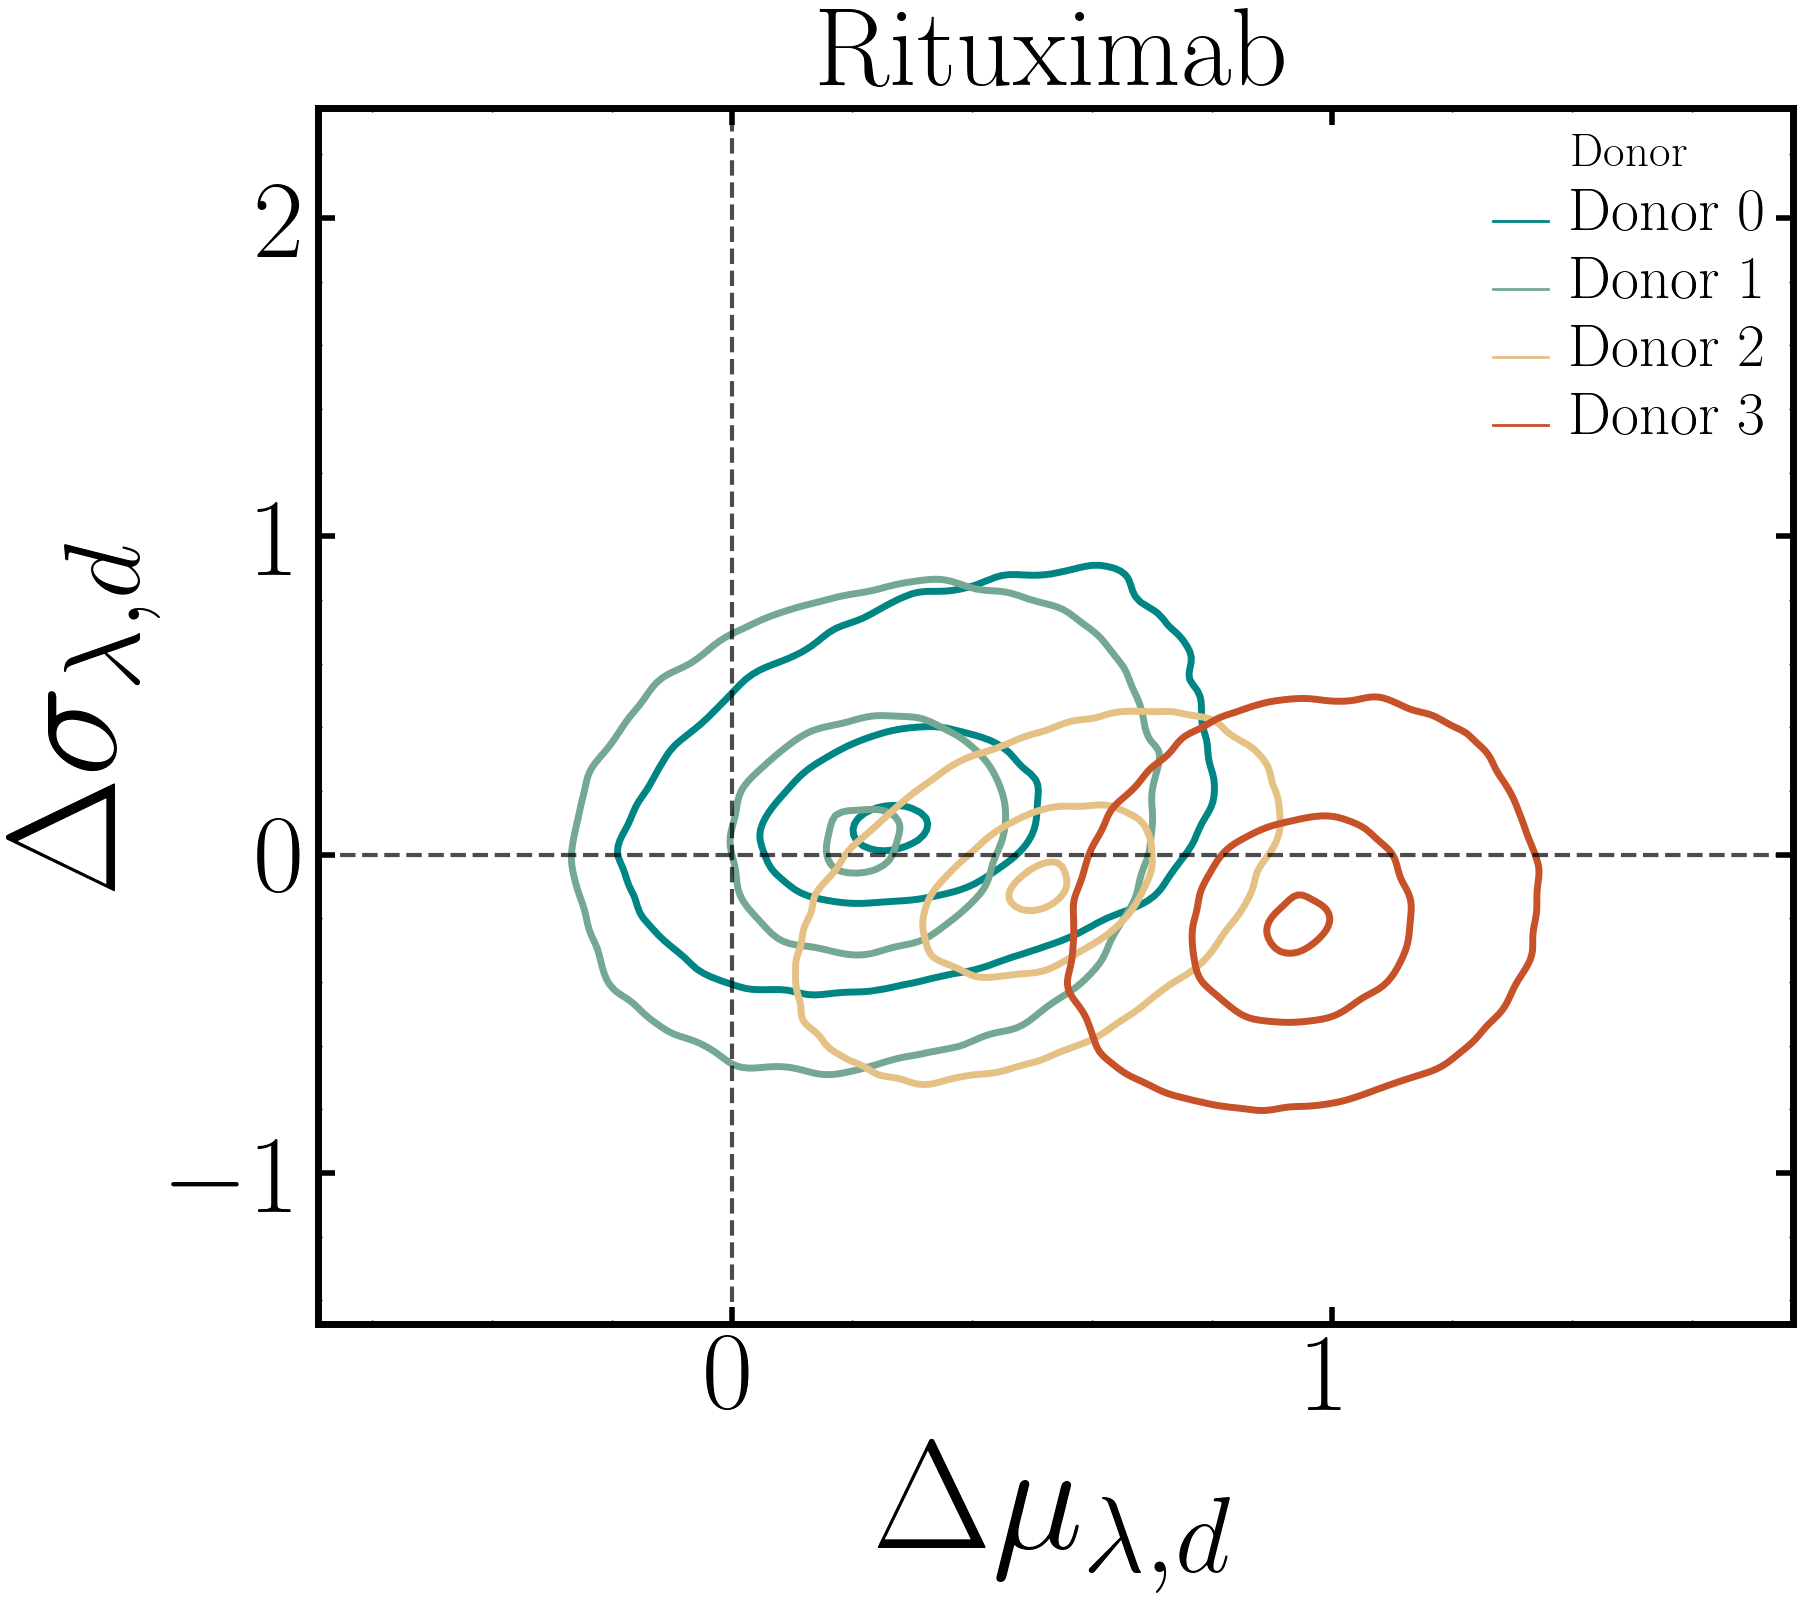

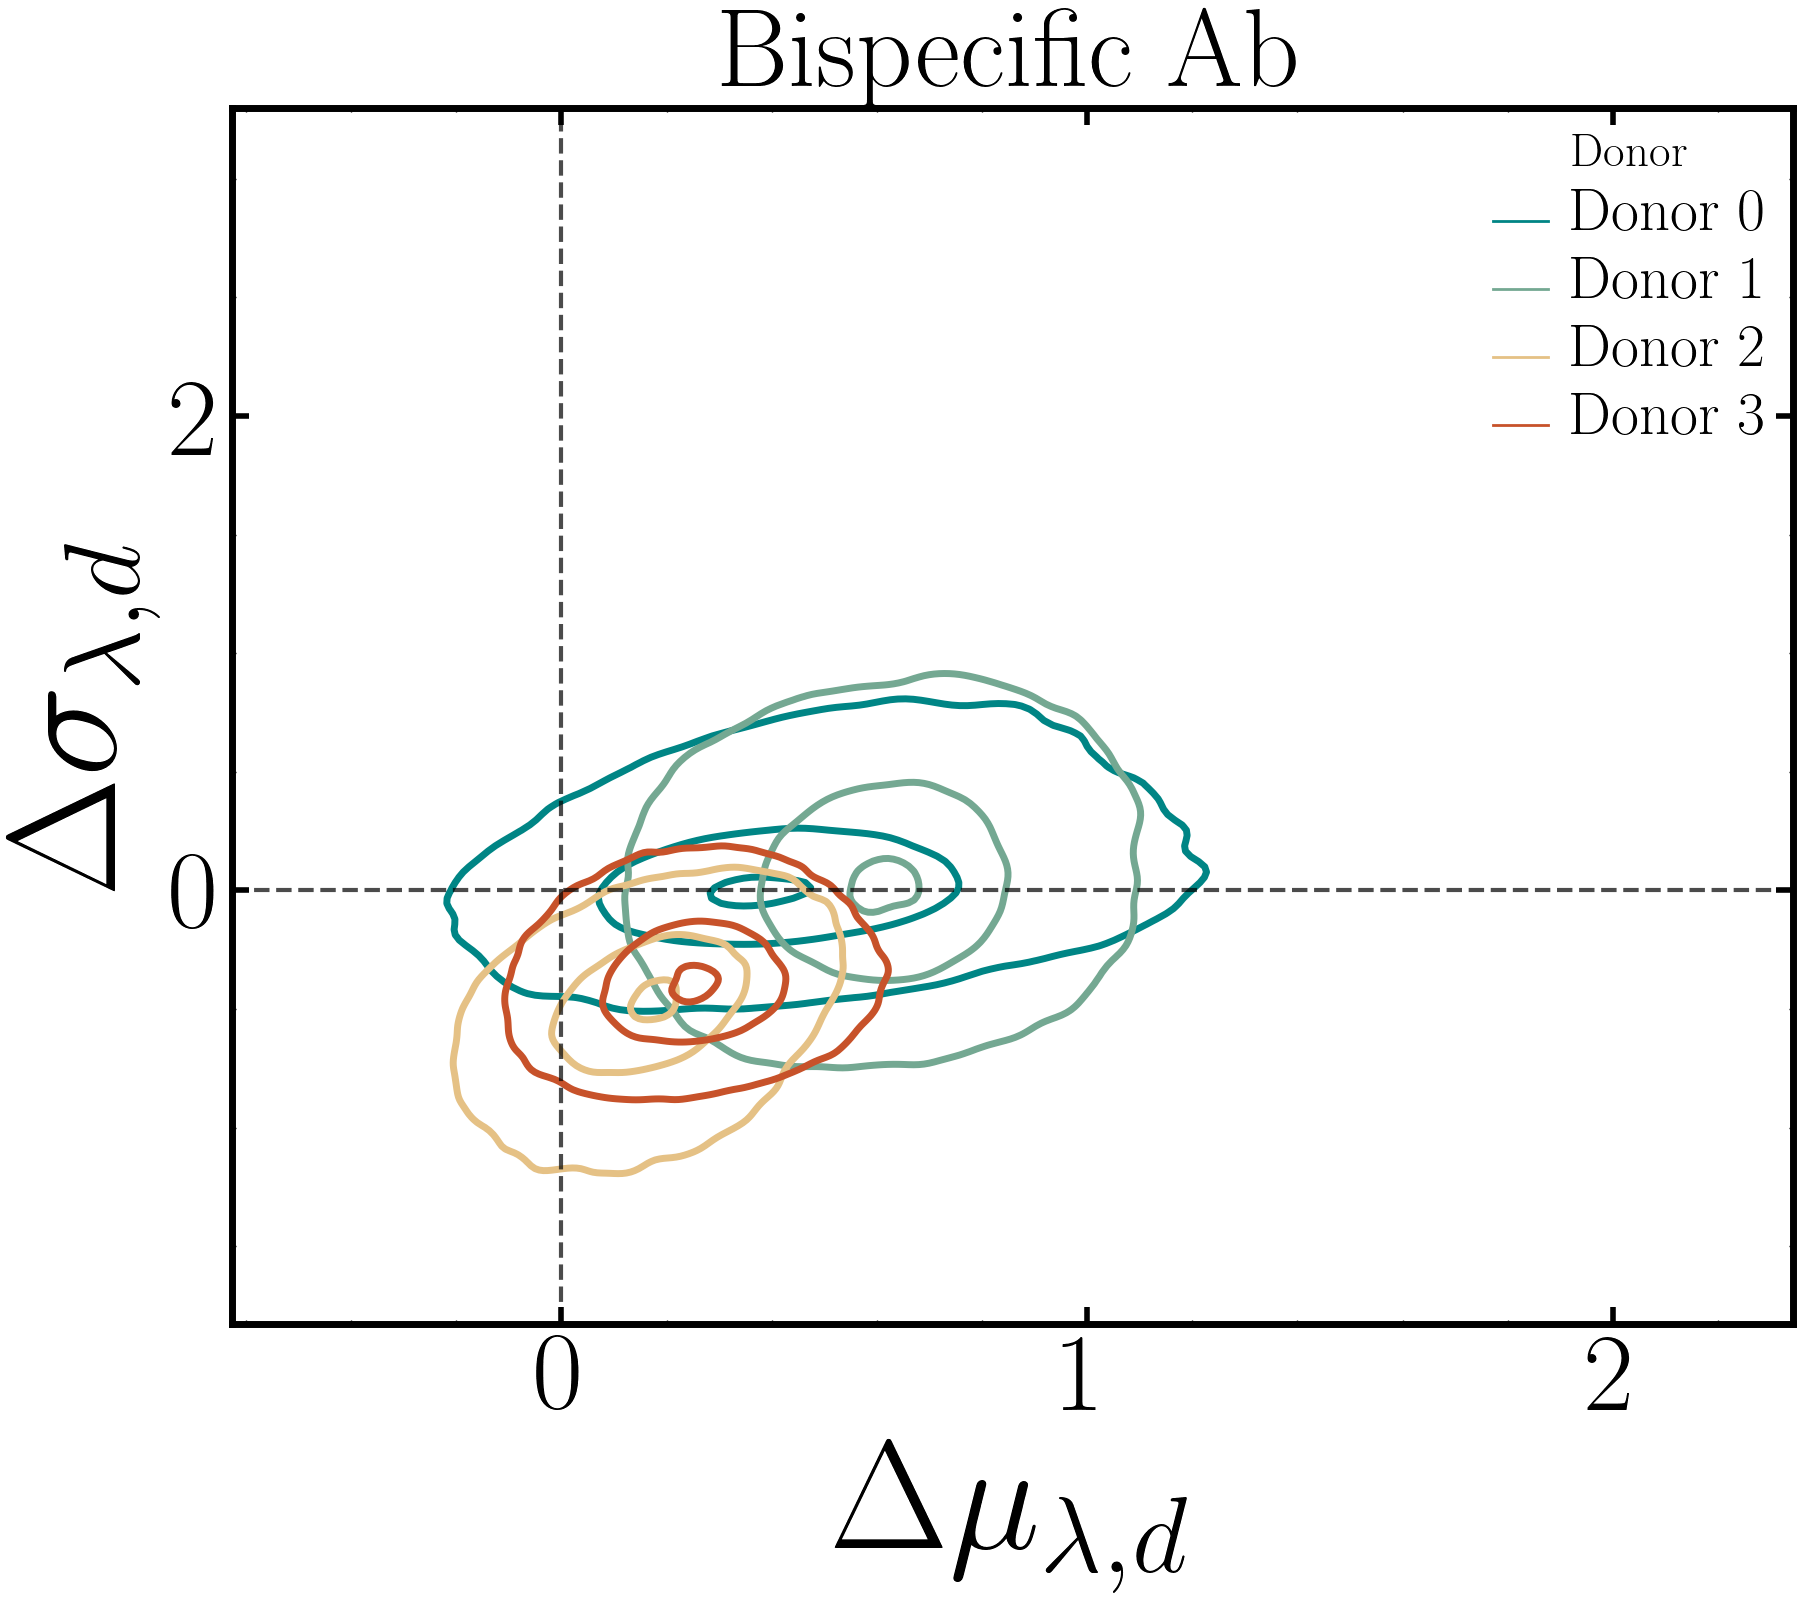

In [13]:
DONOR_COLOR_VALUES = [
    "#008585",
    "#74a892",
    "#e5c185",
    "#c7522a",
]

DONOR_LABELS = [0, 1, 2, 3]
DONOR_NAMES = [
    f"Donor {donor}"
    for donor in DONOR_LABELS
]
DONOR_PALETTE = dict(
    zip(DONOR_NAMES, DONOR_COLOR_VALUES)
)

BASELINE = "No treatment"
TREATMENTS = [
    "Rituximab",
    "Bispecific Ab",
]

# Change to "contacts" when needed.
OUTCOME = "kills"

MAX_EXACT_PAIRS = 500_000
N_APPROXIMATE_PAIRS = 100_000
RANDOM_SEED = 307


def get_joint_donor_samples(
    idata: az.InferenceData,
    donor_index: int,
) -> np.ndarray:
    mu_samples = (
        idata.posterior["mu_lambda_donor"]
        .isel(donor=donor_index)
        .values
        .reshape(-1)
    )

    sigma_samples = (
        idata.posterior["sigma_lambda_donor"]
        .isel(donor=donor_index)
        .values
        .reshape(-1)
    )

    samples = np.column_stack(
        [mu_samples, sigma_samples]
    )

    return samples[
        np.isfinite(samples).all(axis=1)
    ]


def calculate_joint_contrasts(
    treatment_samples: np.ndarray,
    baseline_samples: np.ndarray,
    *,
    rng: np.random.Generator,
) -> tuple[np.ndarray, bool, int]:
    number_of_pairs = (
        len(treatment_samples)
        * len(baseline_samples)
    )

    if number_of_pairs <= MAX_EXACT_PAIRS:
        # Exact Cartesian product:
        # every treatment draw minus every baseline draw.
        differences = (
            treatment_samples[:, None, :]
            - baseline_samples[None, :, :]
        ).reshape(-1, 2)

        exact = True

    else:
        # Uniform Monte Carlo sample from the Cartesian product.
        treatment_indices = rng.integers(
            0,
            len(treatment_samples),
            size=N_APPROXIMATE_PAIRS,
        )
        baseline_indices = rng.integers(
            0,
            len(baseline_samples),
            size=N_APPROXIMATE_PAIRS,
        )

        differences = (
            treatment_samples[treatment_indices]
            - baseline_samples[baseline_indices]
        )

        exact = False

    return differences, exact, number_of_pairs


def make_contrast_dataframe(
    treatment: str,
    outcome: str,
    *,
    treatment_index: int,
) -> pd.DataFrame:
    treatment_idata = posterior_data[
        (treatment, outcome, "Dis2P")
    ]
    baseline_idata = posterior_data[
        (BASELINE, outcome, "Dis2P")
    ]

    frames = []

    for donor_index, donor_name in enumerate(DONOR_NAMES):
        treatment_samples = get_joint_donor_samples(
            treatment_idata,
            donor_index,
        )
        baseline_samples = get_joint_donor_samples(
            baseline_idata,
            donor_index,
        )

        rng = np.random.default_rng(
            RANDOM_SEED
            + 100 * treatment_index
            + donor_index
        )

        differences, exact, number_of_pairs = (
            calculate_joint_contrasts(
                treatment_samples,
                baseline_samples,
                rng=rng,
            )
        )

        frames.append(
            pd.DataFrame(
                {
                    "delta_mu": differences[:, 0],
                    "delta_sigma": differences[:, 1],
                    "donor": donor_name,
                    "exact_cartesian": exact,
                    "possible_pairs": number_of_pairs,
                }
            )
        )

    return pd.concat(
        frames,
        ignore_index=True,
    )


for treatment_index, treatment in enumerate(TREATMENTS):
    contrast_df = make_contrast_dataframe(
        treatment,
        OUTCOME,
        treatment_index=treatment_index,
    )

    fig, ax = plt.subplots(
        figsize=(9, 8),
        dpi=200,
        constrained_layout=True,
    )

    sns.kdeplot(
        data=contrast_df,
        x="delta_mu",
        y="delta_sigma",
        hue="donor",
        hue_order=DONOR_NAMES,
        palette=DONOR_PALETTE,
        levels=[0.05, 0.50, 0.95],
        thresh=0,
        common_norm=False,
        fill=False,
        linewidths=2.5,
        # bw_adjust=1.5,
        ax=ax,
    )
    ax.axvline(
        0,
        color="black",
        linestyle="--",
        linewidth=1.5,
        alpha=0.7,
    )
    ax.axhline(
        0,
        color="black",
        linestyle="--",
        linewidth=1.5,
        alpha=0.7,
    )

    ax.set_xlabel(
        r"$\Delta\mu_{\lambda,d}$",
        fontsize=56,
    )
    ax.set_ylabel(
        r"$\Delta\sigma_{\lambda,d}$",
        fontsize=56,
    )
    ax.set_title(
        f"{treatment}",
        fontsize=40,
    )

    ax.tick_params(
        axis="both",
        labelsize=40,
        width=2,
        length=6,
    )
    
    # ax.set_xlim(-0.5, 1.5)
    # ax.set_ylim(-1.0, 1.0)

    for spine in ax.spines.values():
        spine.set_linewidth(2.5)
    
    fig.patch.set_alpha(0)
    ax.set_facecolor("none")


    legend = ax.get_legend()
    if legend is not None:
        legend.set_title("Donor")
        legend.get_title().set_fontsize(17)

        for text in legend.get_texts():
            text.set_fontsize(22)
    fig.savefig(
        FIGURE_ROOT / f"contrast_{slug(treatment)}_{slug(OUTCOME)}.svg",
        dpi=300,
        bbox_inches="tight",
        transparent=True,
        facecolor="none",
        edgecolor="none",
    )
    plt.show()

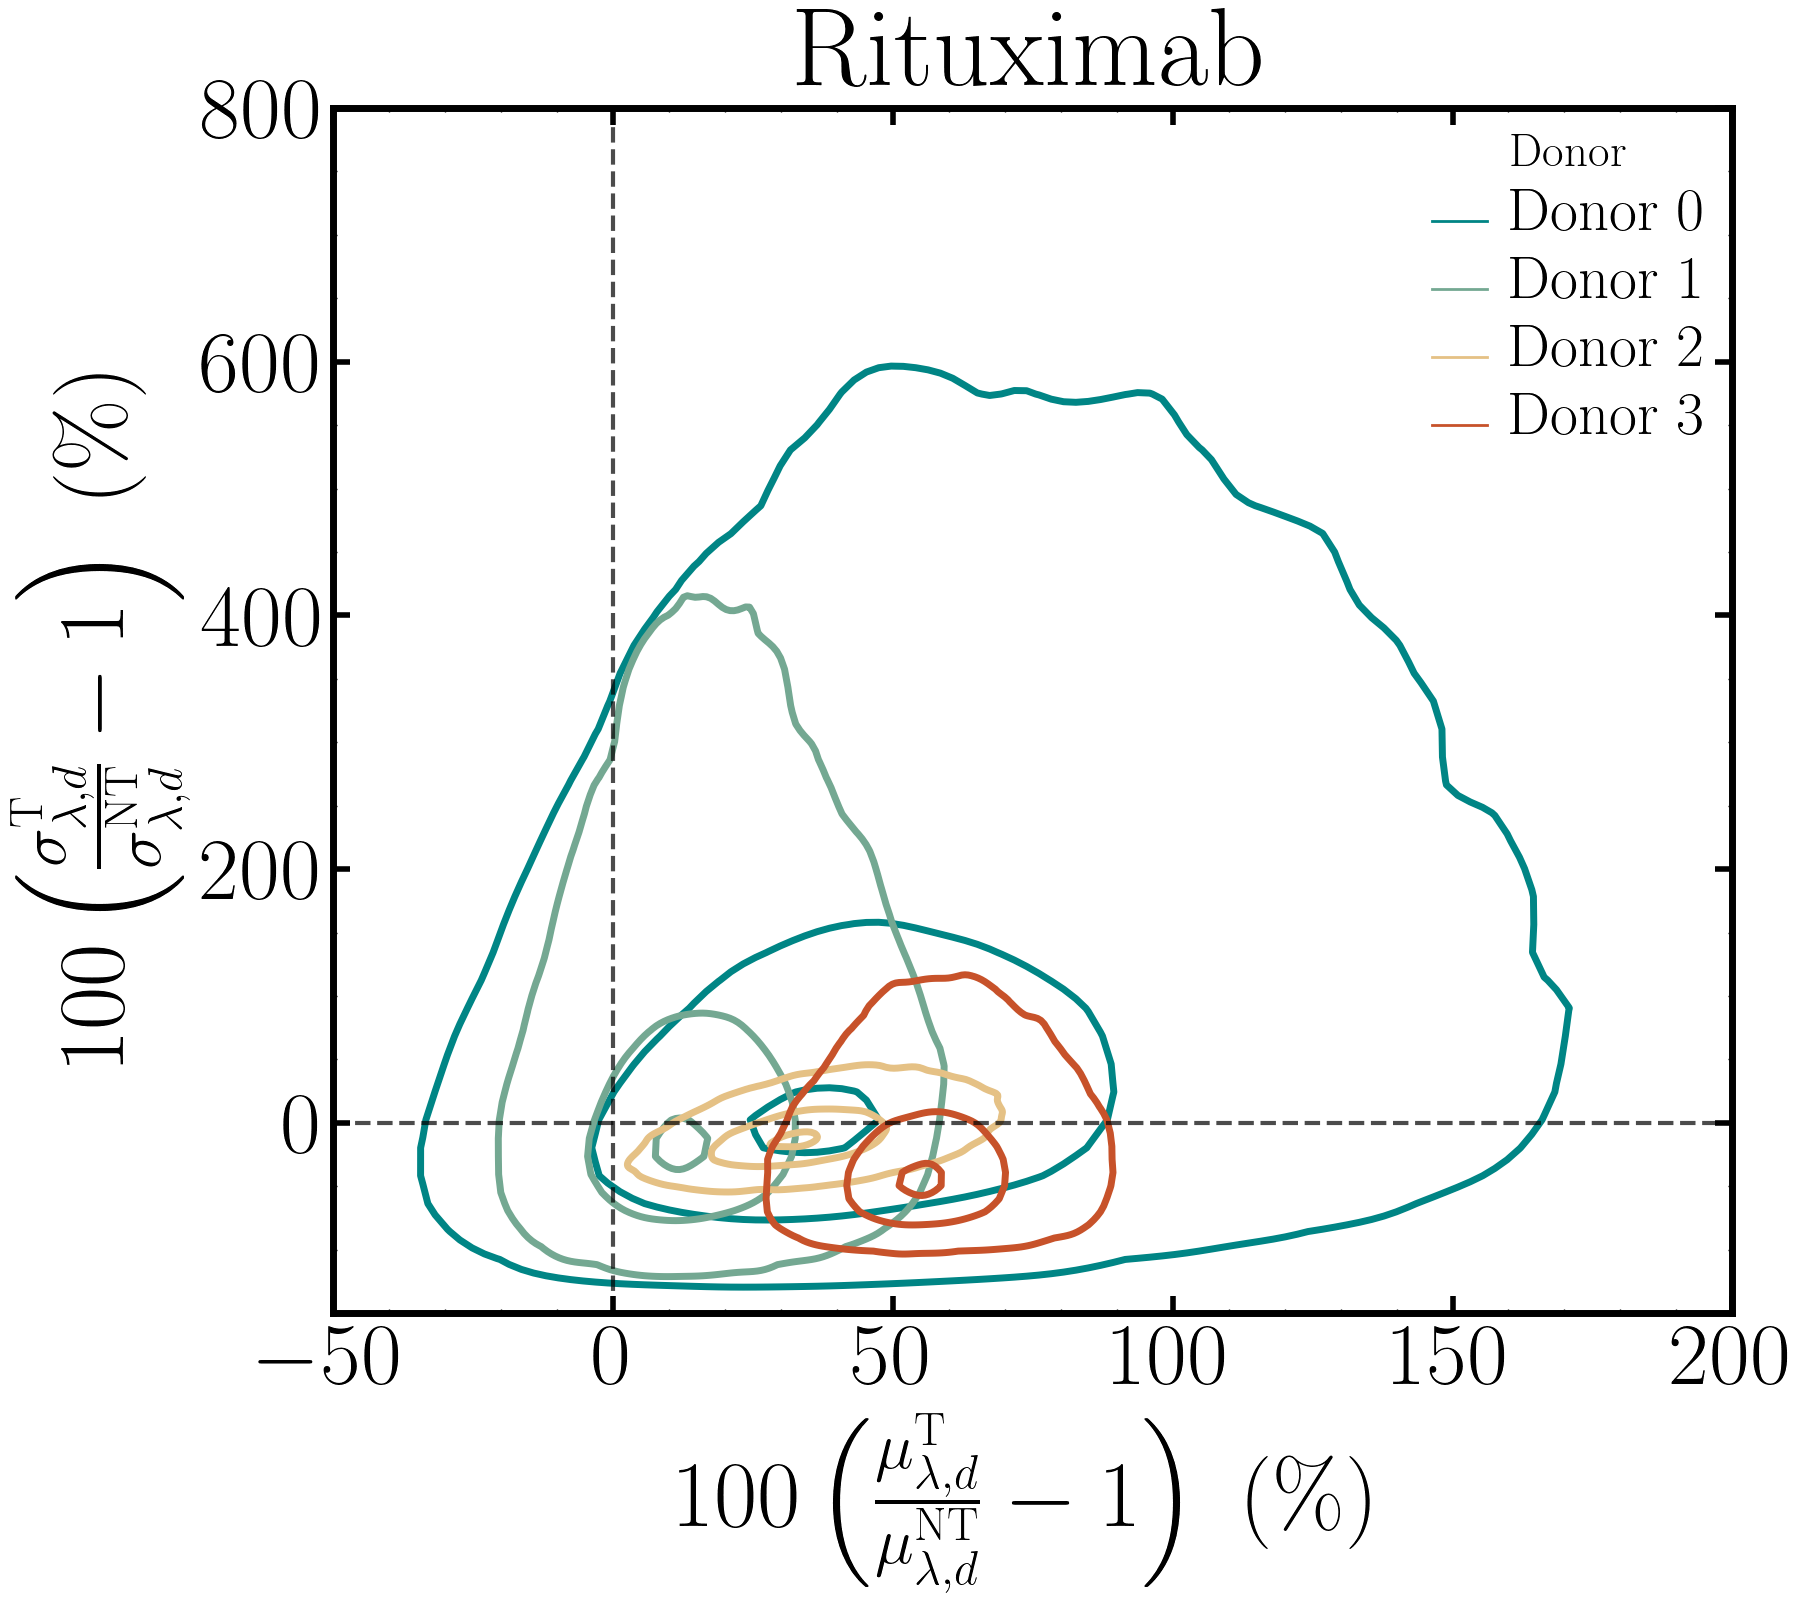

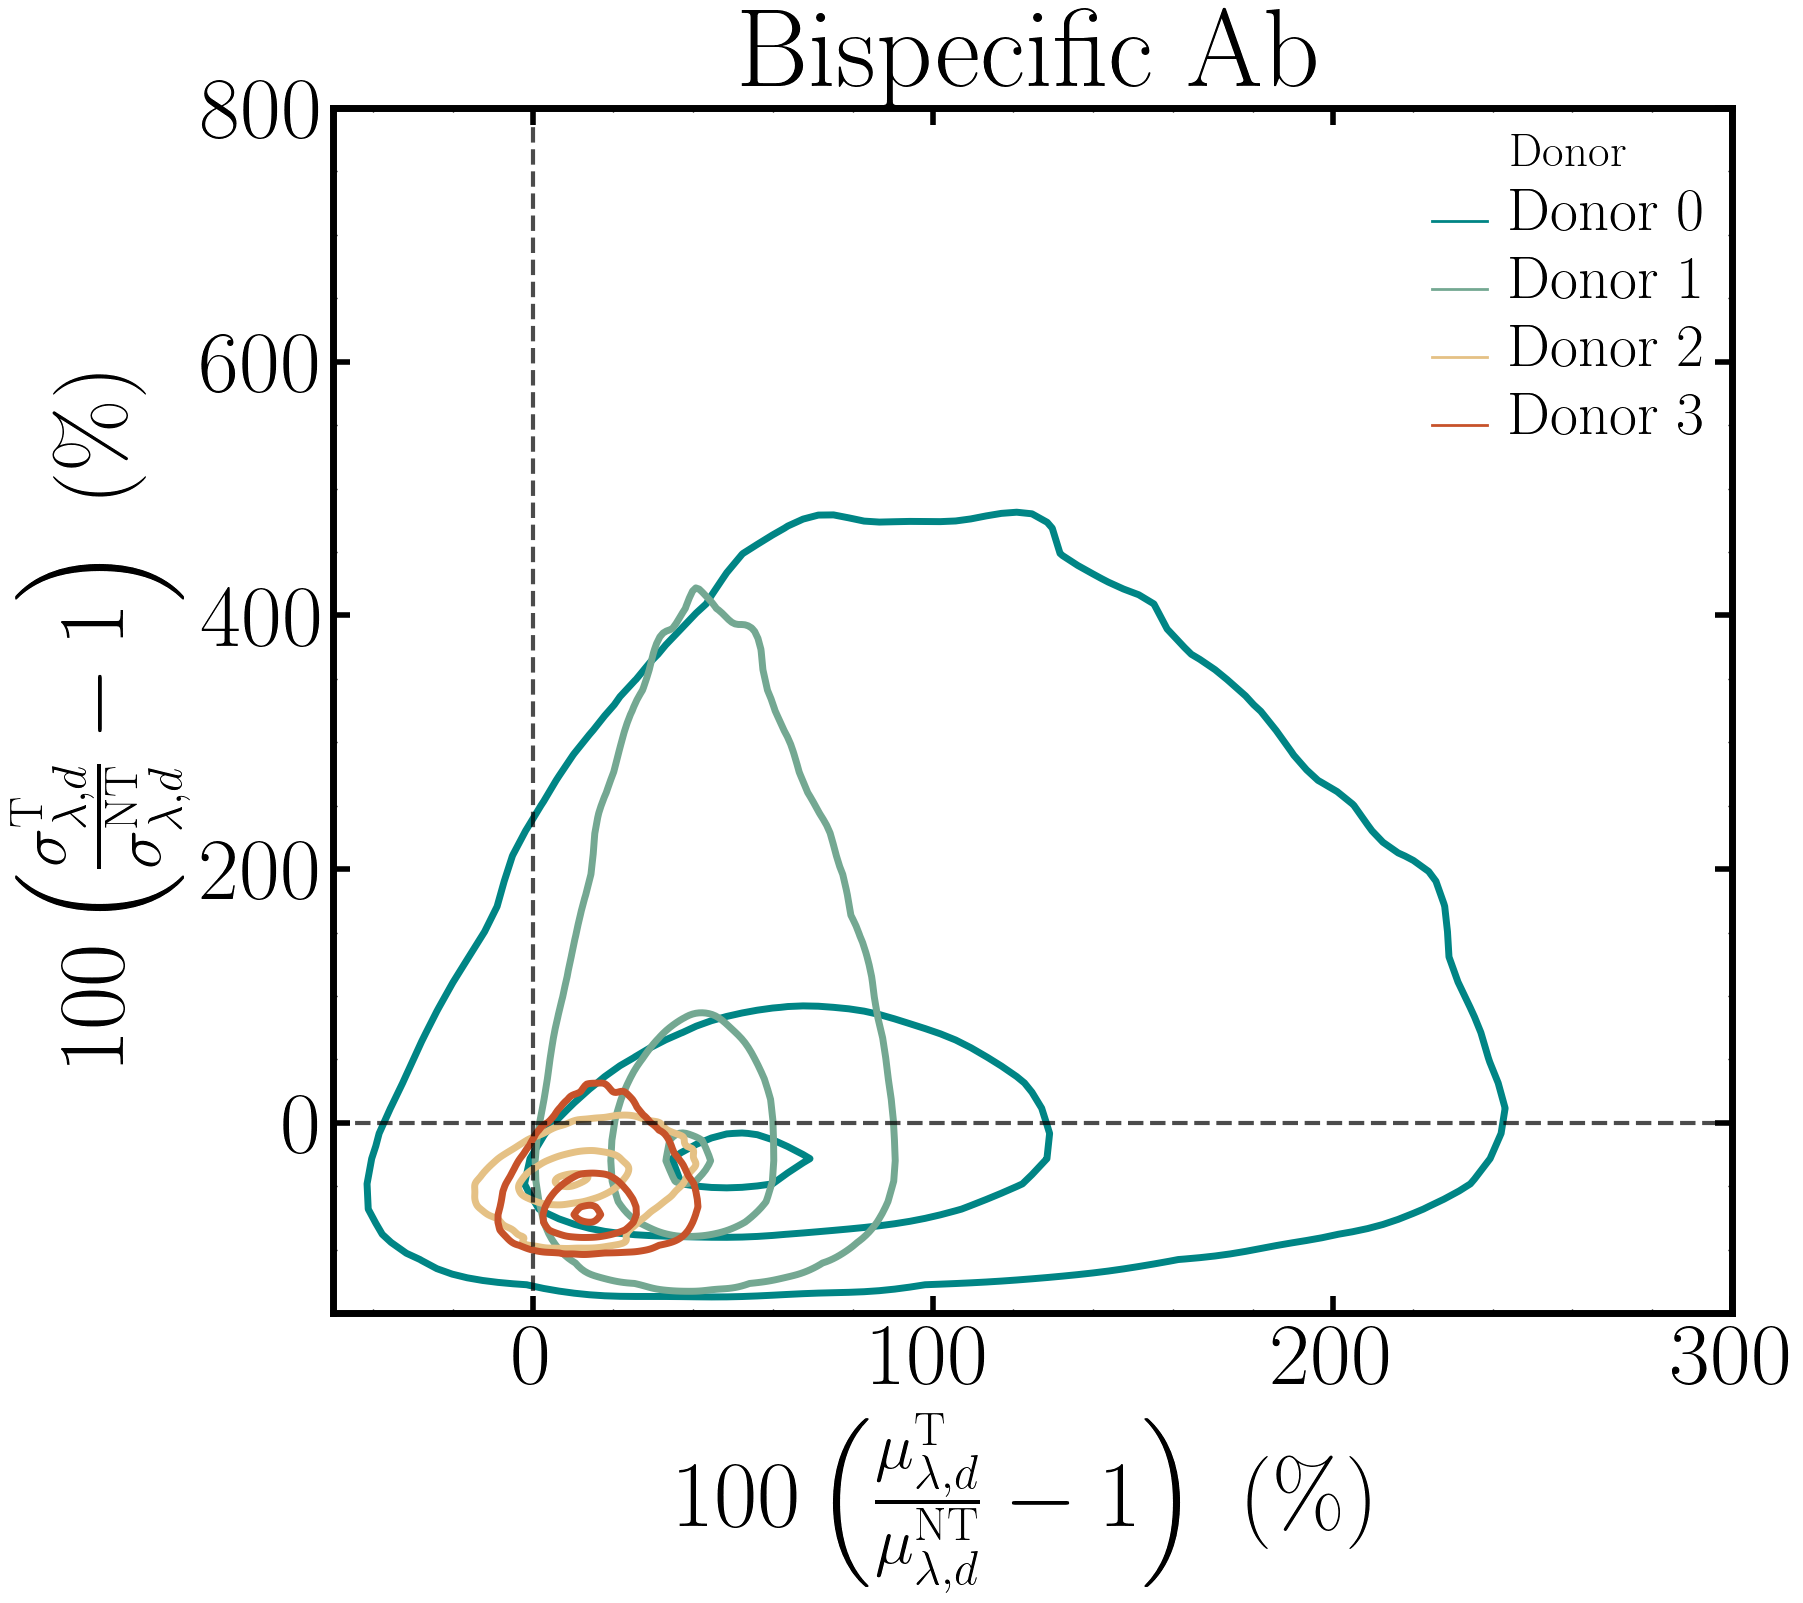

In [27]:
# For every treatment–no-treatment particle pair:
#
# percent Δmu    = 100 * (mu_treatment - mu_no_treatment)
#                       / mu_no_treatment
#
# percent Δsigma = 100 * (sigma_treatment - sigma_no_treatment)
#                       / sigma_no_treatment

MAX_EXACT_PAIRS = 500_000
N_APPROXIMATE_PAIRS = 100_000
RANDOM_SEED = 307

def calculate_joint_percentage_contrasts(
    treatment_samples: np.ndarray,
    baseline_samples: np.ndarray,
    *,
    rng: np.random.Generator,
) -> tuple[np.ndarray, bool, int]:

    if np.any(baseline_samples <= 0):
        raise ValueError(
            "No-treatment mu and sigma particles must be positive."
        )

    number_of_pairs = (
        len(treatment_samples)
        * len(baseline_samples)
    )

    if number_of_pairs <= MAX_EXACT_PAIRS:
        # Every treatment particle paired with every
        # no-treatment particle.
        percent_changes = (
            100.0
            * (
                treatment_samples[:, None, :]
                - baseline_samples[None, :, :]
            )
            / baseline_samples[None, :, :]
        ).reshape(-1, 2)

        exact = True

    else:
        # Random sample of treatment–no-treatment particle pairs.
        treatment_indices = rng.integers(
            0,
            len(treatment_samples),
            size=N_APPROXIMATE_PAIRS,
        )
        baseline_indices = rng.integers(
            0,
            len(baseline_samples),
            size=N_APPROXIMATE_PAIRS,
        )

        paired_treatment = treatment_samples[treatment_indices]
        paired_baseline = baseline_samples[baseline_indices]

        percent_changes = (
            100.0
            * (paired_treatment - paired_baseline)
            / paired_baseline
        )

        exact = False

    percent_changes = percent_changes[
        np.isfinite(percent_changes).all(axis=1)
    ]

    return percent_changes, exact, number_of_pairs


def make_percentage_contrast_dataframe(
    treatment: str,
    outcome: str,
    *,
    treatment_index: int,
) -> pd.DataFrame:

    treatment_idata = posterior_data[
        (treatment, outcome, "Dis2P")
    ]
    baseline_idata = posterior_data[
        (BASELINE, outcome, "Dis2P")
    ]

    frames = []

    for donor_index, donor_name in enumerate(DONOR_NAMES):
        treatment_samples = get_joint_donor_samples(
            treatment_idata,
            donor_index,
        )
        baseline_samples = get_joint_donor_samples(
            baseline_idata,
            donor_index,
        )

        rng = np.random.default_rng(
            RANDOM_SEED
            + 100 * treatment_index
            + donor_index
        )

        percent_changes, exact, number_of_pairs = (
            calculate_joint_percentage_contrasts(
                treatment_samples,
                baseline_samples,
                rng=rng,
            )
        )

        frames.append(
            pd.DataFrame(
                {
                    "percent_delta_mu": percent_changes[:, 0],
                    "percent_delta_sigma": percent_changes[:, 1],
                    "donor": donor_name,
                    "exact_cartesian": exact,
                    "possible_pairs": number_of_pairs,
                }
            )
        )

    return pd.concat(frames, ignore_index=True)


for treatment_index, treatment in enumerate(TREATMENTS):
    percent_contrast_df = make_percentage_contrast_dataframe(
        treatment,
        OUTCOME,
        treatment_index=treatment_index,
    )

    fig, ax = plt.subplots(
        figsize=(9, 8),
        dpi=200,
        constrained_layout=True,
    )

    sns.kdeplot(
        data=percent_contrast_df,
        x="percent_delta_mu",
        y="percent_delta_sigma",
        hue="donor",
        hue_order=DONOR_NAMES,
        palette=DONOR_PALETTE,
        levels=[0.05, 0.50, 0.95],
        thresh=0,
        common_norm=False,
        fill=False,
        linewidths=2.5,
        ax=ax,
    )

    ax.axvline(
        0,
        color="black",
        linestyle="--",
        linewidth=1.5,
        alpha=0.7,
    )
    ax.axhline(
        0,
        color="black",
        linestyle="--",
        linewidth=1.5,
        alpha=0.7,
    )

    ax.set_xlabel(
        r"$100\left("
        r"\frac{\mu_{\lambda,d}^{\mathrm{T}}}"
        r"{\mu_{\lambda,d}^{\mathrm{NT}}}-1"
        r"\right)\;(\%)$",
        fontsize=34,
    )
    ax.set_ylabel(
        r"$100\left("
        r"\frac{\sigma_{\lambda,d}^{\mathrm{T}}}"
        r"{\sigma_{\lambda,d}^{\mathrm{NT}}}-1"
        r"\right)\;(\%)$",
        fontsize=34,
    )
    ax.set_title(treatment, fontsize=40)

    ax.tick_params(
        axis="both",
        labelsize=32,
        width=2,
        length=6,
    )
    
    if treatment_index == 0:
        ax.set_xlim(-50, 200)
        ax.set_ylim(-150, 800)
    elif treatment_index == 1:
        ax.set_xlim(-50, 300)
        ax.set_ylim(-150, 800)

    for spine in ax.spines.values():
        spine.set_linewidth(2.5)

    fig.patch.set_alpha(0)
    ax.set_facecolor("none")

    legend = ax.get_legend()
    if legend is not None:
        legend.set_title("Donor")
        legend.get_title().set_fontsize(17)

        for text in legend.get_texts():
            text.set_fontsize(22)
        
    fig.savefig(
        FIGURE_ROOT / f"percent_contrast_{slug(treatment)}_{slug(OUTCOME)}.svg",
        dpi=300,
        bbox_inches="tight",
        transparent=True,
        facecolor="none",
        edgecolor="none",
    )

    plt.show()

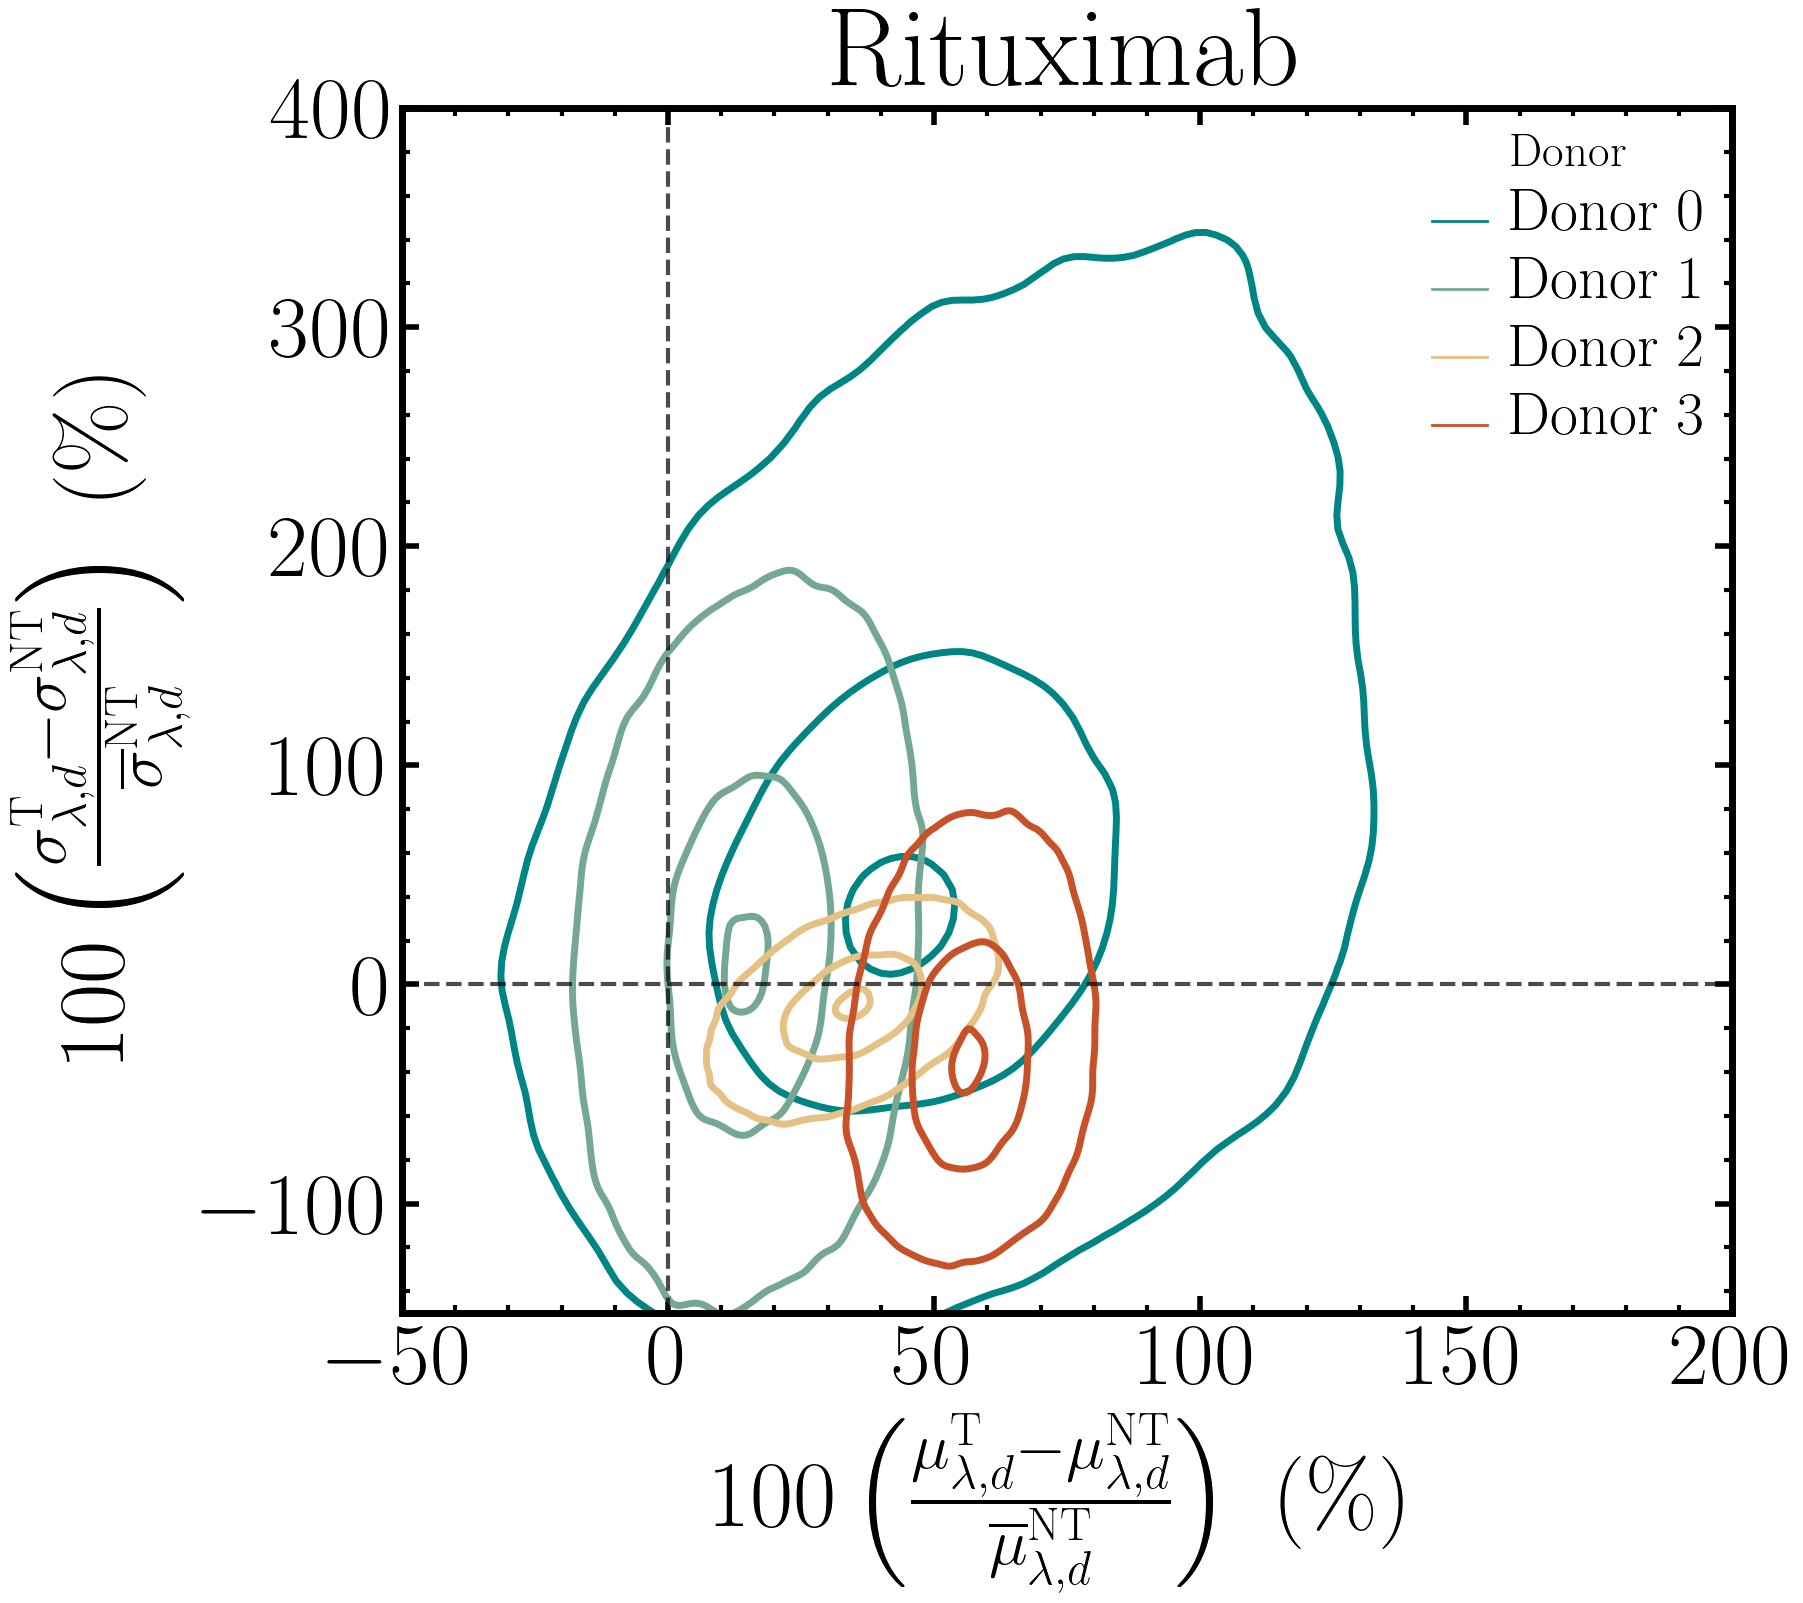

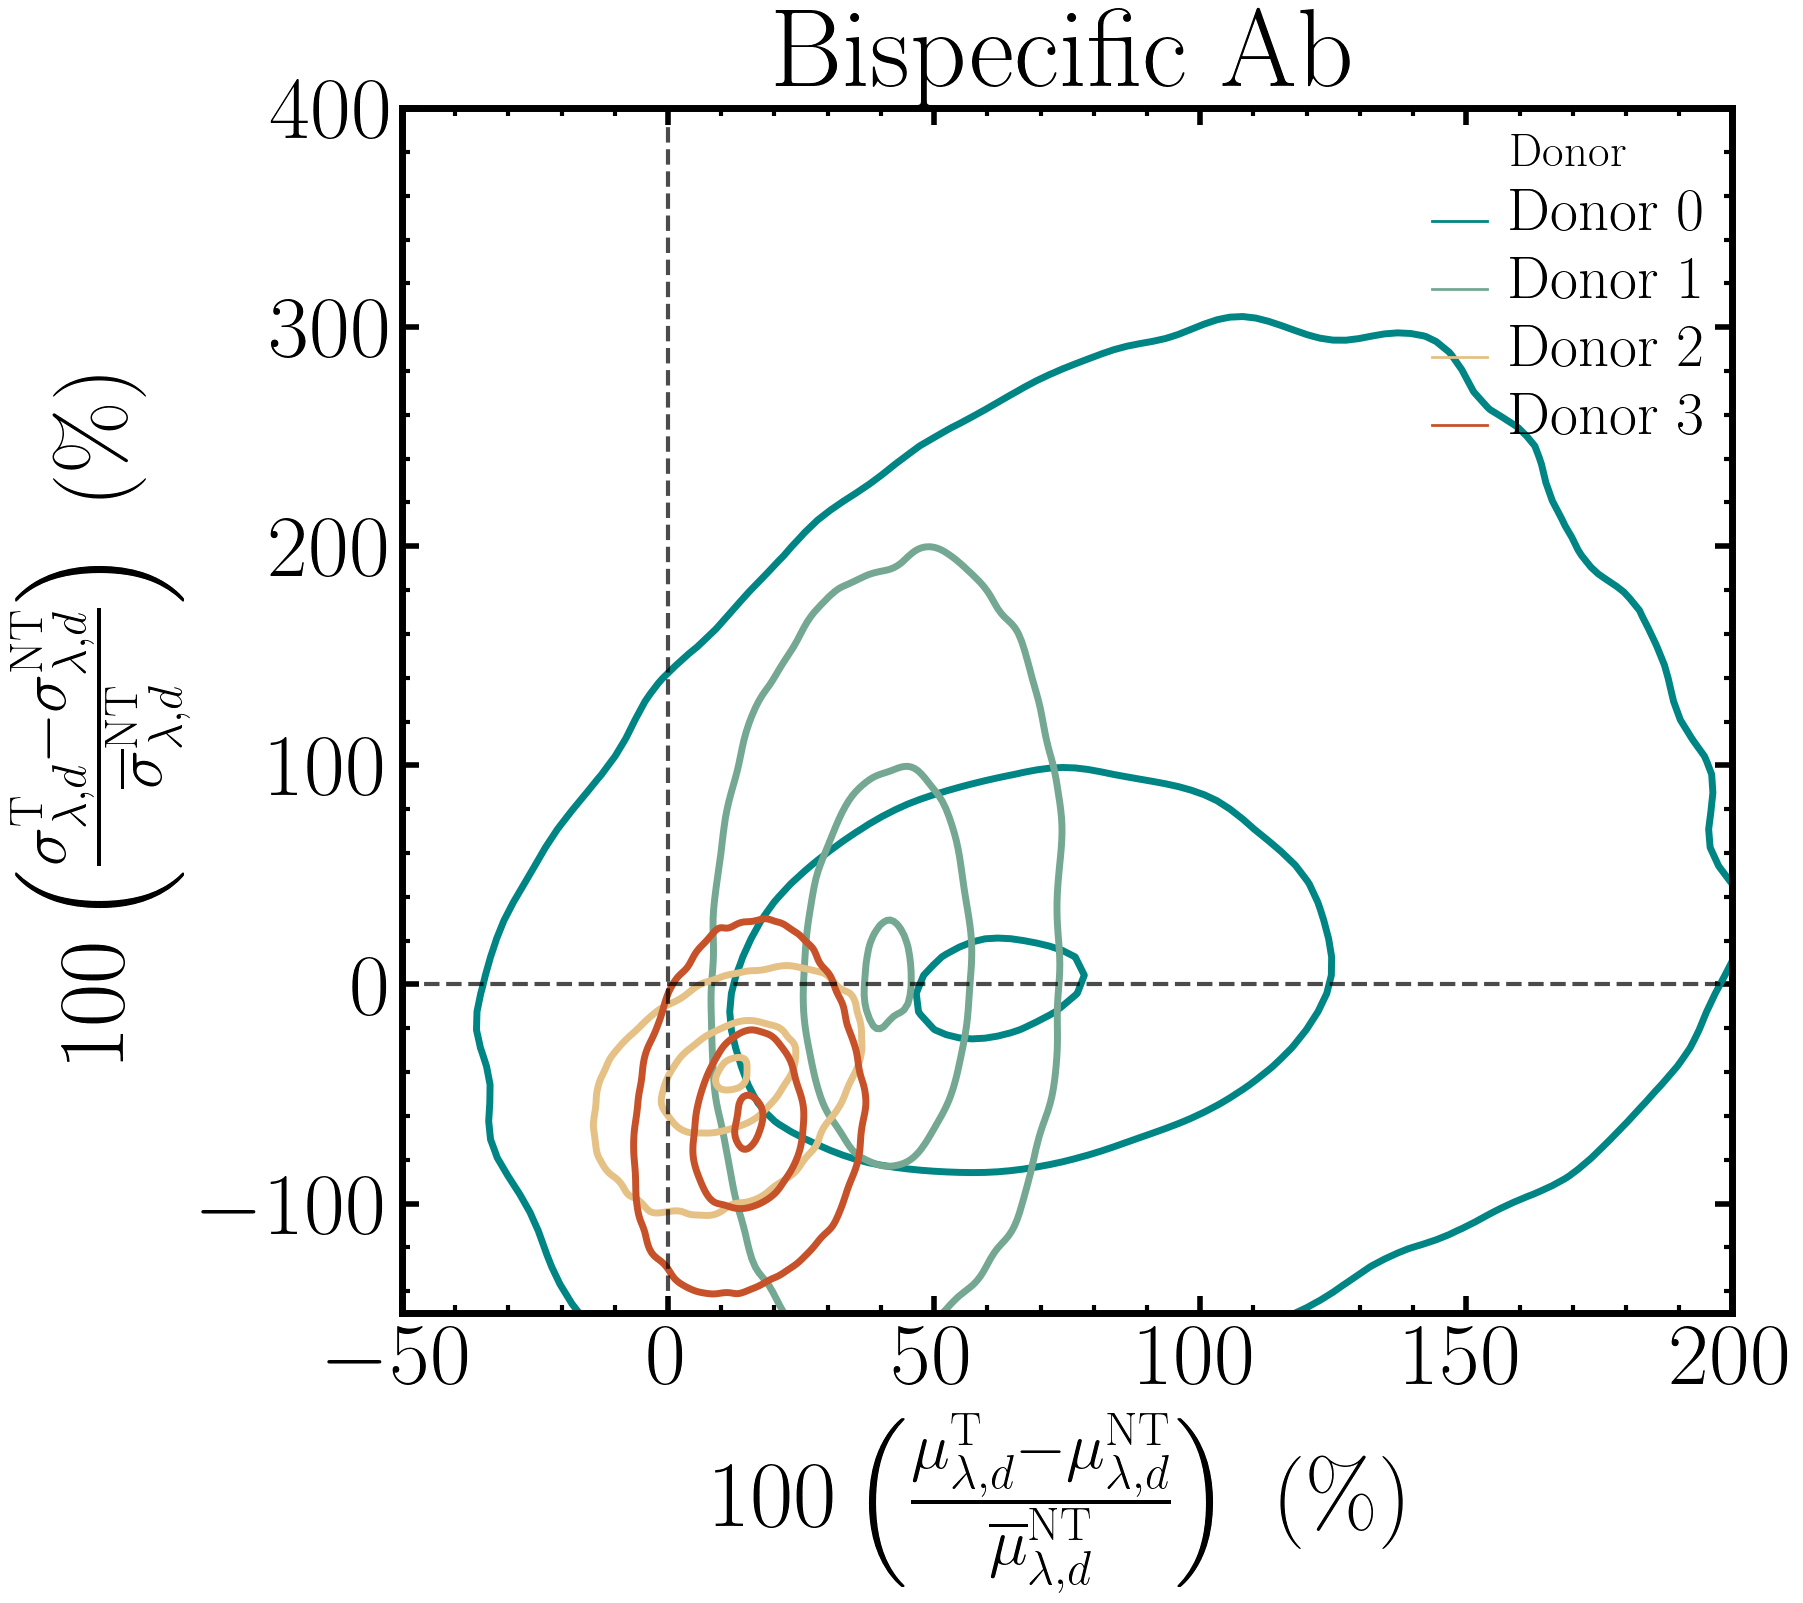

In [36]:
MAX_EXACT_PAIRS = 500_000
N_APPROXIMATE_PAIRS = 100_000
RANDOM_SEED = 307

from matplotlib.ticker import MultipleLocator

def prepare_no_treatment_reference(
    outcome: str,
) -> dict[str, dict[str, np.ndarray]]:
    """
    Store no-treatment samples and donor-specific posterior means.

    Each mean contains:
        [mean(mu), mean(sigma)]
    """
    baseline_idata = posterior_data[
        (BASELINE, outcome, "Dis2P")
    ]

    reference = {}

    for donor_index, donor_name in enumerate(DONOR_NAMES):
        baseline_samples = np.asarray(
            get_joint_donor_samples(
                baseline_idata,
                donor_index,
            ),
            dtype=float,
        )

        baseline_samples = baseline_samples[
            np.isfinite(baseline_samples).all(axis=1)
        ]

        if baseline_samples.size == 0:
            raise ValueError(
                f"No finite no-treatment samples for {donor_name}."
            )

        baseline_mean = baseline_samples.mean(axis=0)

        if (
            not np.isfinite(baseline_mean).all()
            or np.any(baseline_mean <= 0)
        ):
            raise ValueError(
                f"No-treatment posterior means for {donor_name} "
                "must be finite and positive."
            )

        reference[donor_name] = {
            "samples": baseline_samples,
            "mean": baseline_mean,
        }

    return reference


def calculate_joint_percentage_contrasts(
    treatment_samples: np.ndarray,
    baseline_samples: np.ndarray,
    baseline_mean: np.ndarray,
    *,
    rng: np.random.Generator,
) -> tuple[np.ndarray, bool, int]:
    """
    Calculate, for every treatment–no-treatment particle pair,

        100 * (treatment particle - no-treatment particle)
              / posterior mean of no-treatment particles.

    The denominator is fixed within each donor.
    """
    treatment_samples = np.asarray(
        treatment_samples,
        dtype=float,
    )

    treatment_samples = treatment_samples[
        np.isfinite(treatment_samples).all(axis=1)
    ]

    baseline_samples = np.asarray(
        baseline_samples,
        dtype=float,
    )

    baseline_samples = baseline_samples[
        np.isfinite(baseline_samples).all(axis=1)
    ]

    baseline_mean = np.asarray(
        baseline_mean,
        dtype=float,
    )

    if treatment_samples.size == 0:
        raise ValueError(
            "No finite treatment posterior samples."
        )

    if baseline_samples.size == 0:
        raise ValueError(
            "No finite no-treatment posterior samples."
        )

    if baseline_mean.shape != (2,):
        raise ValueError(
            "baseline_mean must contain [mean_mu, mean_sigma]."
        )

    if (
        not np.isfinite(baseline_mean).all()
        or np.any(baseline_mean <= 0)
    ):
        raise ValueError(
            "No-treatment posterior means must be finite and positive."
        )

    number_of_pairs = (
        len(treatment_samples)
        * len(baseline_samples)
    )

    if number_of_pairs <= MAX_EXACT_PAIRS:
        differences = (
            treatment_samples[:, None, :]
            - baseline_samples[None, :, :]
        )

        percent_changes = (
            100.0
            * differences
            / baseline_mean[None, None, :]
        ).reshape(-1, 2)

        exact = True

    else:
        treatment_indices = rng.integers(
            0,
            len(treatment_samples),
            size=N_APPROXIMATE_PAIRS,
        )

        baseline_indices = rng.integers(
            0,
            len(baseline_samples),
            size=N_APPROXIMATE_PAIRS,
        )

        differences = (
            treatment_samples[treatment_indices]
            - baseline_samples[baseline_indices]
        )

        percent_changes = (
            100.0
            * differences
            / baseline_mean[None, :]
        )

        exact = False

    percent_changes = percent_changes[
        np.isfinite(percent_changes).all(axis=1)
    ]

    return percent_changes, exact, number_of_pairs


def make_percentage_contrast_dataframe(
    treatment: str,
    outcome: str,
    *,
    treatment_index: int,
    baseline_reference: dict[str, dict[str, np.ndarray]],
) -> pd.DataFrame:
    treatment_idata = posterior_data[
        (treatment, outcome, "Dis2P")
    ]

    frames = []

    for donor_index, donor_name in enumerate(DONOR_NAMES):
        treatment_samples = get_joint_donor_samples(
            treatment_idata,
            donor_index,
        )

        baseline_samples = baseline_reference[
            donor_name
        ]["samples"]

        baseline_mean = baseline_reference[
            donor_name
        ]["mean"]

        rng = np.random.default_rng(
            RANDOM_SEED
            + 100 * treatment_index
            + donor_index
        )

        percent_changes, exact, number_of_pairs = (
            calculate_joint_percentage_contrasts(
                treatment_samples,
                baseline_samples,
                baseline_mean,
                rng=rng,
            )
        )

        frames.append(
            pd.DataFrame(
                {
                    "percent_delta_mu": percent_changes[:, 0],
                    "percent_delta_sigma": percent_changes[:, 1],
                    "donor": donor_name,
                    "baseline_mean_mu": baseline_mean[0],
                    "baseline_mean_sigma": baseline_mean[1],
                    "exact_cartesian": exact,
                    "possible_pairs": number_of_pairs,
                }
            )
        )

    return pd.concat(
        frames,
        ignore_index=True,
    )


# Compute the no-treatment posterior means once.
baseline_reference = prepare_no_treatment_reference(
    OUTCOME
)

for treatment_index, treatment in enumerate(TREATMENTS):
    percent_contrast_df = make_percentage_contrast_dataframe(
        treatment,
        OUTCOME,
        treatment_index=treatment_index,
        baseline_reference=baseline_reference,
    )

    fig, ax = plt.subplots(
        figsize=(9, 8),
        dpi=200,
        constrained_layout=True,
    )

    sns.kdeplot(
        data=percent_contrast_df,
        x="percent_delta_mu",
        y="percent_delta_sigma",
        hue="donor",
        hue_order=DONOR_NAMES,
        palette=DONOR_PALETTE,
        levels=[0.05, 0.50, 0.95],
        thresh=0,
        common_norm=False,
        fill=False,
        linewidths=2.5,
        ax=ax,
    )

    ax.axvline(
        0,
        color="black",
        linestyle="--",
        linewidth=1.5,
        alpha=0.7,
    )
    ax.axhline(
        0,
        color="black",
        linestyle="--",
        linewidth=1.5,
        alpha=0.7,
    )

    ax.set_xlabel(
        r"$100\left("
        r"\frac{\mu_{\lambda,d}^{\mathrm{T}}"
        r"-\mu_{\lambda,d}^{\mathrm{NT}}}"
        r"{\overline{\mu}_{\lambda,d}^{\mathrm{NT}}}"
        r"\right)\;(\%)$",
        fontsize=34,
    )
    ax.set_ylabel(
        r"$100\left("
        r"\frac{\sigma_{\lambda,d}^{\mathrm{T}}"
        r"-\sigma_{\lambda,d}^{\mathrm{NT}}}"
        r"{\overline{\sigma}_{\lambda,d}^{\mathrm{NT}}}"
        r"\right)\;(\%)$",
        fontsize=34,
    )
    ax.set_title(treatment, fontsize=40)
    
    ax.xaxis.set_major_locator(MultipleLocator(50))
    ax.yaxis.set_major_locator(MultipleLocator(100))
    
    ax.tick_params(
        axis="both",
        which="major",
        labelsize=32,
        width=2,
        length=6,
    )
    ax.tick_params(
        axis="both",
        which="minor",
        width=1.5,
        length=3,
    )
    ax.set_xlim(-50, 200)
    ax.set_ylim(-150, 400)
    # if treatment_index == 0:
    #     ax.set_xlim(-50, 200)
    #     ax.set_ylim(-150, 400)
    # elif treatment_index == 1:
    #     ax.set_xlim(-50, 200)
    #     ax.set_ylim(-150, 400)

    for spine in ax.spines.values():
        spine.set_linewidth(2.5)

    fig.patch.set_alpha(0)
    ax.set_facecolor("none")

    legend = ax.get_legend()
    if legend is not None:
        legend.set_title("Donor")
        legend.get_title().set_fontsize(17)

        for text in legend.get_texts():
            text.set_fontsize(22)
        
    fig.savefig(
        FIGURE_ROOT / f"percent_contrast_{slug(treatment)}_{slug(OUTCOME)}.svg",
        dpi=300,
        bbox_inches="tight",
        transparent=True,
        facecolor="none",
        edgecolor="none",
    )

    plt.show()